In [16]:
import sys, os
ROOT = os.path.abspath(os.curdir)
sys.path.append(os.path.abspath(os.path.join(ROOT,'src')))

# SET VALUES TO MATCH EXPERIMENT
LOAD_DIR = os.path.join(ROOT,'results')

import irl_maxent.gridworld as W
import irl_maxent.plot as P
import irl_maxent.solver as S

import mix_irl.irleed as I
import mix_irl.helpers as H
import mix_irl.irl as IRL

import numpy as np
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from itertools import product       

import pickle
from tqdm import trange

from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection

import json

In [17]:
ORANGE = '#FF9132'
RED   = '#B02105'
PINK = '#E600BF'
TEAL = '#0598B0'
GREEN = '#008F00'
PURPLE = '#8A2BE2'
GRAY = '#969696'
FIG_WIDTH = 3
FIG_HEIGHT = 3.5
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 8,
    "axes.titlesize": 10,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "lines.linewidth": 2
})
# global style for plots
style = {                                   
    'border': {'color': 'black', 'linewidth': 0.5},
    # 'border': None
}

legend_key = ['Dem.',
              'IRL', 
              'IRLEED',
              ]
color_key = [GRAY,
             ORANGE, 
             GREEN,
            ]       

## Gridworld

In [3]:
# UTILITIES

def normalize(vec):
    a, b = float(np.min(vec)), float(np.max(vec))
    return (vec - a) / (b - a + 1e-12)

# def load_cell(LOAD_DIR, beta, lam, eps_str, env_id=1):
#     base = (
#         f"{LOAD_DIR}/gridworld_simple/irleed/env_{env_id}/"
#         f"demo_beta_{beta:.3f}/{eps_str}"
#     )
#     if eps_str == "noeps":
#         result_path = f"{base}/baseline.p"
#     else:
#         result_path = f"{base}/lam_{lam:.3f}.p"

#     options, data = pickle.load(open(result_path, "rb"))
#     return options, data, result_path

def load_cell(LOAD_DIR, beta_tag, lam, eps_str, env_id=1):
    base = f"{LOAD_DIR}/gridworld_simple/irleed/env_{env_id}/{beta_tag}/{eps_str}"
    if eps_str == "noeps":
        result_path = f"{base}/baseline.p"
    else:
        result_path = f"{base}/lam_{lam:.3f}.p"

    options, data = pickle.load(open(result_path, "rb"))
    return options, data, result_path

def _preterminal_states_list(states, terminal_set):
    """Return prefix of states up to (and including) first terminal, or all if none."""
    out = []
    for s in states:
        out.append(s)
        if s in terminal_set:
            break
    return out

def compute_visit_stats(world, trajectories, terminal_states=None, preterminal=False):
    """
    Returns:
      occ_counts[s]  = total number of visits to state s (sum over all traj/time)
      hit_counts[s]  = number of trajectories that ever visited s
      dwell_sum[s]   = sum over trajectories of V_i(s) but only for those with V_i(s)>0 (same as occ_counts)
      total_steps    = sum of trajectory lengths (in states, i.e., len(states))
      N              = number of trajectories
    """
    nS = world.n_states
    occ_counts = np.zeros(nS, dtype=np.float64)
    hit_counts = np.zeros(nS, dtype=np.float64)
    total_steps = 0.0
    N = len(trajectories)

    term_set = set(terminal_states) if terminal_states is not None else None

    for t in trajectories:
        ss = list(t.states())
        if preterminal and term_set is not None:
            ss = _preterminal_states_list(ss, term_set)

        total_steps += len(ss)

        # per-trajectory visit counts
        v = np.zeros(nS, dtype=np.float64)
        for s in ss:
            v[int(s)] += 1.0

        occ_counts += v
        hit_counts += (v > 0).astype(np.float64)

    return occ_counts, hit_counts, total_steps, N

def stats_to_maps(occ_counts, hit_counts, total_steps, N, eps=1e-12):
    """
    Returns:
      f_occ[s]        = occupancy frequency = occ_counts / total_steps
      p_hit[s]        = hit rate            = hit_counts / N
      dwell_given_hit = mean visits given hit = occ_counts / hit_counts
      E_V[s]          = mean visits per trajectory = occ_counts / N
    """
    f_occ = occ_counts / (total_steps + eps)
    p_hit = hit_counts / (N + eps)
    dwell_given_hit = occ_counts / (hit_counts + eps)
    E_V = occ_counts / (N + eps)
    return f_occ, p_hit, dwell_given_hit, E_V

def _trajectory_segments_with_time(world, t):
    """Return line segments [(p0,p1),...] and a time scalar per segment in [0,1]."""
    ss = list(t.states())
    pts = np.array([world.state_index_to_point(s) for s in ss], dtype=float)
    if len(pts) < 2:
        return np.zeros((0, 2, 2)), np.zeros((0,))
    segs = np.stack([pts[:-1], pts[1:]], axis=1)  # (T-1, 2, 2)
    times = np.linspace(0.0, 1.0, num=len(segs), endpoint=True)
    return segs, times

def _draw_grid(ax, size, lw=0.6):
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    for i in range(size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], linewidth=lw)
        ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], linewidth=lw)

def _plot_one_traj(
    ax,
    world,
    t,
    cmap="viridis",
    alpha=1.0,
    lw=1.7,
    label_start_end=True,
    idx=None,
    lane_radius=0.14,        # how far we can move inside a cell
    max_lanes=12,             # how many distinct revisit lanes
    dir_lane_mag=0.02,       # extra offset based on direction
):
    """
    Plot one trajectory with lane offsets so revisits don't overlap.
    """
    ss = list(t.states())
    if len(ss) == 0:
        return

    pts = np.array([world.state_index_to_point(s) for s in ss], dtype=float)

    # Build visit counts per state as we walk through the trajectory
    seen = {}
    pts_off = pts.copy()

    for i, s in enumerate(ss):
        s = int(s)
        v = seen.get(s, 0)            # visit index for this state
        seen[s] = v + 1

        # offset due to revisit "lane"
        ox, oy = _lane_offset(v, max_lanes=max_lanes, radius=lane_radius)

        # optional extra offset based on local direction (helps separate edges)
        if i < len(ss) - 1:
            x, y = pts[i]
            xn, yn = pts[i + 1]
            dx, dy = (xn - x), (yn - y)
        else:
            dx, dy = (pts[i] - pts[i - 1]) if i > 0 else (0.0, 0.0)

        px, py = _direction_lane(dx, dy, mag=dir_lane_mag)

        pts_off[i, 0] += ox + px
        pts_off[i, 1] += oy + py

    # Build segments + time for colormap
    if len(pts_off) >= 2:
        segs = np.stack([pts_off[:-1], pts_off[1:]], axis=1)
        times = np.linspace(0.0, 1.0, num=len(segs), endpoint=True)

        lc = LineCollection(segs, cmap=cmap, array=times, linewidths=lw, alpha=alpha)
        ax.add_collection(lc)

    # start/end markers use the *offset* points so they match the drawn path
    ax.scatter(pts_off[0, 0], pts_off[0, 1], s=55, marker="o", zorder=5)
    ax.scatter(pts_off[-1, 0], pts_off[-1, 1], s=65, marker="x", zorder=5)

    if label_start_end:
        s_txt = "S" if idx is None else f"S{idx}"
        e_txt = "E" if idx is None else f"E{idx}"
        ax.text(pts_off[0, 0] + 0.12, pts_off[0, 1] + 0.12, s_txt, fontsize=9, weight="bold")
        ax.text(pts_off[-1, 0] + 0.12, pts_off[-1, 1] + 0.12, e_txt, fontsize=9, weight="bold")

def _lane_offset(visit_idx, max_lanes=8, radius=0.22):
    """
    Return a small (dx, dy) offset in a repeating 'ring' pattern.
    radius is in cell units; keep <= ~0.25 to stay inside cell.
    """
    if visit_idx <= 0:
        return 0.0, 0.0

    k = (visit_idx - 1) % max_lanes
    # evenly spaced angles around a circle
    theta = 2.0 * np.pi * (k / max_lanes)
    return radius * np.cos(theta), radius * np.sin(theta)


def _direction_lane(dx, dy, mag=0.10):
    """
    Small perpendicular offset based on direction of motion.
    Helps separate repeated back-and-forth edges.
    """
    if dx == 0 and dy == 0:
        return 0.0, 0.0

    # perpendicular to (dx,dy): (-dy, dx)
    px, py = -dy, dx
    norm = np.hypot(px, py)
    px, py = px / (norm + 1e-12), py / (norm + 1e-12)
    return mag * px, mag * py

def aggregate_cell(
    data,
    max_T=None,
    n_features=49,
    beta_max=1e6,
    drop_bad_beta_seeds=True,
    eps_max=1e6,
    drop_bad_eps_seeds=False,
    theta_max=300,
    drop_bad_theta_seeds=True,
    ratios=None
):
    if max_T is None:
        raise ValueError("Pass max_T explicitly, e.g. max_T=options['max_steps']")
    max_T = int(max_T)

    returns = np.zeros(3)
    feat_sum = np.zeros(n_features)
    theta_sum = np.zeros((2, n_features))
    count = 0

    visit_sum = np.zeros(n_features, dtype=np.float64)
    visit_count = 0

    eps_sum = None
    eps_hist_sum = None
    eps_hist_count = None

    betas_hist_sum = None
    betas_hist_count = None

    # NEW: theta history accumulators
    theta_hist_sum = None          # (max_T, F)
    theta_hist_count = None        # (max_T, F)

    K = None

    for dat in data:
        if dat is None:
            continue
        
        # ----- normal aggregates -----
        returns[0] += dat["dem_rews"]
        rews = dat["log"]["rewards"]
        returns[1] += rews[0]
        returns[2] += rews[1] if len(rews) > 1 else rews[0]

        scales = np.array(dat["mix_e_features"]).max(axis=1)
        feat_sum += ((np.array(dat["mix_e_features"]).T / scales).T).mean(axis=0)

        theta_sum[0] += np.array(dat["log"]["theta"][0]).reshape(-1)
        theta_sum[1] += np.array(dat["log"]["theta"][-1]).reshape(-1)

        # ----- NEW: theta history -----
        th_hist = dat["log"].get("theta", None)
        if th_hist is not None and len(th_hist) > 0:
            th_arr = np.stack([np.array(th).reshape(-1) for th in th_hist], axis=0)  # (t,F)
            bad_th = (not np.all(np.isfinite(th_arr))) or (np.nanmax(np.abs(th_arr)) > theta_max)
            if drop_bad_theta_seeds and bad_th:
                pass
            else:
                t_seed = th_arr.shape[0]
                th_pad = np.full((max_T, n_features), np.nan, dtype=np.float64)
                tt = min(max_T, t_seed)
                th_pad[:tt] = th_arr[:tt]

                if theta_hist_sum is None:
                    theta_hist_sum = np.zeros((max_T, n_features), dtype=np.float64)
                    theta_hist_count = np.zeros((max_T, n_features), dtype=np.float64)

                mask = np.isfinite(th_pad)
                theta_hist_sum[mask] += th_pad[mask]
                theta_hist_count[mask] += 1.0

        # ----- eps final + eps history (your code) -----
        if "epsilons" in dat["log"] and dat["log"]["epsilons"] is not None and len(dat["log"]["epsilons"]) > 0:
            eps_list_final = dat["log"]["epsilons"][-1]
            eps_stack_final = np.stack([np.array(e).reshape(-1) for e in eps_list_final], axis=0)
            if eps_sum is None:
                K = eps_stack_final.shape[0]
                eps_sum = np.zeros((K, n_features))
            eps_sum += eps_stack_final

            eps_hist_list = dat["log"]["epsilons"]
            t_seed = len(eps_hist_list)
            K_seed = len(eps_hist_list[0])

            eps_hist = np.stack(
                [np.stack([np.array(e).reshape(-1) for e in eps_hist_list[t]], axis=0) for t in range(t_seed)],
                axis=0
            )

            bad_eps = (not np.all(np.isfinite(eps_hist))) or (np.nanmax(np.abs(eps_hist)) > eps_max)
            if drop_bad_eps_seeds and bad_eps:
                pass
            else:
                eps_pad = np.full((max_T, K_seed, n_features), np.nan, dtype=np.float64)
                tt = min(max_T, t_seed)
                eps_pad[:tt] = eps_hist[:tt]

                if eps_hist_sum is None:
                    eps_hist_sum = np.zeros((max_T, K_seed, n_features), dtype=np.float64)
                    eps_hist_count = np.zeros((max_T, K_seed, n_features), dtype=np.float64)

                mask = np.isfinite(eps_pad)
                eps_hist_sum[mask] += eps_pad[mask]
                eps_hist_count[mask] += 1.0

        # ----- beta history (your code) -----
        if "betas" in dat["log"] and dat["log"]["betas"] is not None and len(dat["log"]["betas"]) > 0:
            b_hist = np.stack(dat["log"]["betas"], axis=0)
            bad_beta = (not np.all(np.isfinite(b_hist))) or (np.nanmax(np.abs(b_hist)) > beta_max)
            if drop_bad_beta_seeds and bad_beta:
                pass
            else:
                K2 = b_hist.shape[1]
                b_pad = np.full((max_T, K2), np.nan, dtype=np.float64)
                tt = min(max_T, b_hist.shape[0])
                b_pad[:tt] = b_hist[:tt]

                if betas_hist_sum is None:
                    betas_hist_sum = np.zeros((max_T, K2), dtype=np.float64)
                    betas_hist_count = np.zeros((max_T, K2), dtype=np.float64)

                mask = np.isfinite(b_pad)
                betas_hist_sum[mask] += b_pad[mask]
                betas_hist_count[mask] += 1.0

        count += 1

    if count == 0:
        raise RuntimeError("No non-None seeds in this file.")

    returns_mean = returns / count
    theta_pair_mean = theta_sum / count
    feat_mean = feat_sum / count
    # visit_mean = (visit_sum / (visit_count + 1e-12)) if visit_count > 0 else None
    eps_final_mean = (eps_sum / count) if eps_sum is not None else None

    betas_hist_mean = None
    if betas_hist_sum is not None:
        betas_hist_mean = betas_hist_sum / (betas_hist_count + 1e-12)

    eps_hist_mean = None
    if eps_hist_sum is not None:
        eps_hist_mean = eps_hist_sum / (eps_hist_count + 1e-12)

    # NEW: theta_hist_mean
    theta_hist_mean = None
    if theta_hist_sum is not None:
        theta_hist_mean = theta_hist_sum / (theta_hist_count + 1e-12)  # (T,F)

    return returns_mean, theta_pair_mean, feat_mean, eps_final_mean, eps_hist_mean, betas_hist_mean, theta_hist_mean, count, K, max_T


def get_true_beta_from_cell(data, key="true_betas"):
    """
    Returns:
      beta_true_mean: (K,) mean true beta vector across valid seeds
      beta_true_all:  (N_valid, K) stacked true betas (for debugging)
    """
    arr = []
    for dat in data:
        if dat is None:
            continue
        tb = dat.get(key, None)
        if tb is None:
            continue
        tb = np.array(tb, dtype=np.float64).reshape(-1)
        if np.all(np.isfinite(tb)):
            arr.append(tb)

    if len(arr) == 0:
        raise RuntimeError(f"No '{key}' found in this cell's seeds.")

    beta_true_all = np.stack(arr, axis=0)              # (N_valid, K)
    beta_true_mean = beta_true_all.mean(axis=0)        # (K,)
    return beta_true_mean, beta_true_all

def get_first_valid_seed(data):
    for i, dat in enumerate(data):
        if dat is not None:
            return i, dat
    raise RuntimeError("No non-None seeds found.")


def print_traj_length_stats(trajectories, label=""):
    """
    Print summary stats of trajectory lengths.

    length := number of states in traj = len(list(traj.states()))
    (num transitions would be length - 1)
    """
    lengths = np.array([len(list(tr.states())) for tr in trajectories], dtype=np.int64)

    if len(lengths) == 0:
        print(f"[traj len stats] {label}: no trajectories")
        return lengths

    q = np.percentile(lengths, [5, 25, 50, 75, 95])

    print(f"\n[traj len stats] {label}")
    print(f"  n      = {len(lengths)}")
    print(f"  min    = {lengths.min()}")
    print(f"  max    = {lengths.max()}")
    print(f"  mean   = {lengths.mean():.2f}")
    print(f"  std    = {lengths.std(ddof=0):.2f}")
    print(f"  median = {np.median(lengths):.2f}")
    print(f"  q05/q25/q50/q75/q95 = {q[0]:.1f}/{q[1]:.1f}/{q[2]:.1f}/{q[3]:.1f}/{q[4]:.1f}")

    return lengths
    

def compute_empirical_policy_from_transitions(
    world,
    trajectories,
    n_actions=None,
    preterminal_only=False,
    terminal_states=None,
):
    """
    Build empirical pi_hat(a|s) from Trajectory.transitions(): (s, a, s').
    Returns:
      pi_hat: (n_states, n_actions)
      counts: (n_states, n_actions)
      state_visits_as_source: (n_states,)
    """
    n_states = world.n_states
    if n_actions is None:
        # Try common attributes; otherwise fall back to max action seen + 1
        n_actions = getattr(world, "n_actions", None)

    terminal_set = set(int(s) for s in terminal_states) if terminal_states is not None else set()

    # If we couldn't infer n_actions, we will infer it from data in a first pass.
    if n_actions is None:
        max_a = -1
        for traj in trajectories:
            for (_, a, _) in traj.transitions():
                max_a = max(max_a, int(a))
        n_actions = max_a + 1
        if n_actions <= 0:
            raise ValueError("Could not infer n_actions (no transitions?).")

    counts = np.zeros((n_states, n_actions), dtype=np.int64)
    state_visits_as_source = np.zeros(n_states, dtype=np.int64)

    for traj in trajectories:
        trans = list(traj.transitions())
        if len(trans) == 0:
            continue

        # Optionally stop counting after first terminal is reached (preterminal)
        if preterminal_only and terminal_states is not None:
            cut = None
            # terminal is reached when *current state* is terminal OR next state is terminal;
            # for action-at-state counting, we usually stop once current state is terminal.
            for i, (s, a, sp) in enumerate(trans):
                if int(s) in terminal_set:
                    cut = i
                    break
            if cut is not None:
                trans = trans[:cut]  # exclude actions taken *from* terminal

        for (s, a, sp) in trans:
            s = int(s); a = int(a)
            if a < 0 or a >= n_actions:
                # Safety in case of unexpected action ids
                continue
            counts[s, a] += 1
            state_visits_as_source[s] += 1

    pi_hat = np.zeros_like(counts, dtype=np.float64)
    mask = state_visits_as_source > 0
    pi_hat[mask] = counts[mask] / state_visits_as_source[mask][:, None]

    return pi_hat, counts, state_visits_as_source

In [4]:
def infer_action_mapping(
    world,
    anchor_points=None,
    p_threshold=0.9,
    verbose=True,
):
    """
    Infer action-index -> direction label mapping from world.p_transition.

    - Picks a set of interior "anchor" states.
    - For each action a:
        * checks the most likely next state sp from each anchor state
        * measures displacement (dx, dy)
        * aggregates the most common displacement across anchors
    - Returns:
        mapping: dict[int -> str]
        info: dict with diagnostics per action

    Labels:
        R, L, U, D, Stay, Other(dx,dy)
    """

    # ----- choose interior anchors (avoid boundaries) -----
    size = world.size
    if anchor_points is None:
        # some safe interior points (if size=7, these are inside)
        candidates = [(2,2), (3,2), (2,3), (3,3), (4,3), (3,4)]
        anchor_points = [(x,y) for (x,y) in candidates
                         if (0 < x < size-1) and (0 < y < size-1)]
        if len(anchor_points) == 0:
            # fallback: pick any non-terminal states or any state
            anchor_points = [(size//2, size//2)]

    # convert anchor points -> states
    anchor_states = []
    for (x,y) in anchor_points:
        # try to locate converter; otherwise brute search
        if hasattr(world, "point_to_state_index"):
            s = world.point_to_state_index((x,y))
        else:
            # brute
            s = None
            for si in range(world.n_states):
                xi, yi = world.state_index_to_point(si)
                if (int(xi), int(yi)) == (x,y):
                    s = si
                    break
            if s is None:
                continue
        anchor_states.append(int(s))

    n_actions = getattr(world, "n_actions", None)
    if n_actions is None:
        # infer from p_transition shape if not available
        n_actions = world.p_transition.shape[2]

    def dxdy_to_label(dx, dy):
        if dx == 1 and dy == 0:  return "R"
        if dx == -1 and dy == 0: return "L"
        if dx == 0 and dy == 1:  return "U"
        if dx == 0 and dy == -1: return "D"
        if dx == 0 and dy == 0:  return "Stay"
        return f"Other({dx},{dy})"

    mapping = {}
    info = {}

    for a in range(n_actions):
        dxdy_votes = []
        ambiguity_flags = []

        for s in anchor_states:
            p = world.p_transition[s, :, a]
            # most likely next
            sp = int(np.argmax(p))
            pmax = float(p[sp])

            x, y = world.state_index_to_point(s)
            xp, yp = world.state_index_to_point(sp)

            dx = int(round(xp - x))
            dy = int(round(yp - y))

            dxdy_votes.append((dx, dy))

            # ambiguity check: is there significant probability mass on other next states?
            # measure how concentrated the distribution is
            top2 = np.partition(p, -2)[-2:]
            second = float(np.min(top2))
            ambiguous = (pmax < p_threshold) or (second > 0.1)
            ambiguity_flags.append(ambiguous)

        # majority displacement
        unique, counts = np.unique(dxdy_votes, axis=0, return_counts=True)
        best_idx = int(np.argmax(counts))
        best_dxdy = tuple(unique[best_idx])
        label = dxdy_to_label(*best_dxdy)

        mapping[a] = label
        info[a] = {
            "label": label,
            "majority_dxdy": best_dxdy,
            "votes": dxdy_votes,
            "vote_counts": dict((tuple(u), int(c)) for u, c in zip(unique, counts)),
            "ambiguous_any": bool(np.any(ambiguity_flags)),
            "ambiguous_fraction": float(np.mean(ambiguity_flags)),
            "anchors_used": len(anchor_states),
        }

    # ----- pretty print -----
    if verbose:
        print("=== Inferred action mapping ===")
        for a in range(n_actions):
            amb = info[a]["ambiguous_fraction"]
            warn = "  ⚠️ ambiguous" if info[a]["ambiguous_any"] else ""
            print(f"action {a} -> {mapping[a]}   votes={info[a]['vote_counts']}   ambig={amb:.2f}{warn}")

        # Recommend an action_names list in correct index order
        print("\nSuggested action_names =")
        print([mapping[a] for a in range(n_actions)])

    return mapping, info

In [5]:
# PLOTTERS

def plot_heatmap_and_return(results_for_beta, lams, beta, eps_str, save_dir, fig_prefix="IRL_vs_IRLEED"):
    # results_for_beta: (len(lams), 3) where [dem, irl, irleed]
    dem_rew   = results_for_beta[:, 0]
    irl_rew   = results_for_beta[:, 1]
    irleed_rew= results_for_beta[:, 2]

    heatmap = (irleed_rew / (irl_rew + 1e-12)) * 100.0  # (len(lams),)

    fig = plt.figure(figsize=(3.2, 2.0))
    spec = fig.add_gridspec(ncols=2, nrows=1, width_ratios=[0.5, 0.5],
                            left=0.07, right=0.99, top=0.88, bottom=0.13)
    spec.update(wspace=0.3, hspace=0)
    ax_heat = fig.add_subplot(spec[0, 0])
    ax_rew  = fig.add_subplot(spec[0, 1])

    fig.suptitle(fr'IRLEED vs IRL | $\beta_{{demo}}$={beta:.3f} | {eps_str}')

    # heat "map": make it 2D for imshow: (1, len(lams))
    divider = make_axes_locatable(ax_heat)
    cax = divider.append_axes('bottom', size='5%', pad=0.05)
    p = ax_heat.imshow(heatmap[None, :], origin='lower', vmin=100, cmap='Greens', aspect='auto')
    cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
    cbar.set_ticks([100, 150, 200])
    cbar.set_ticklabels(["$100\\%$", "$150\\%$", "$200\\%$"])
    cbar.ax.tick_params(size=0)

    ax_heat.set_ylabel(r'$\beta$ index', labelpad=2)  # not super meaningful now
    ax_heat.set_xlabel(r'$\lambda$ index', labelpad=3)
    cax.set_xlabel('relative performance', labelpad=0)
    ax_heat.set_xticks([]); ax_heat.set_yticks([])
    ax_heat.spines['left'].set_visible(False)
    ax_heat.spines['bottom'].set_visible(False)
    ax_heat.xaxis.set_label_position('top')

    # return lines across lambdas
    ax_rew.plot(np.arange(len(lams)), irl_rew, label='IRL')
    ax_rew.plot(np.arange(len(lams)), irleed_rew, label='IRLEED')
    ax_rew.legend()
    ax_rew.set_ylabel('episode return', labelpad=0)
    ax_rew.set_xlabel(r'$\lambda$ index')
    ax_rew.set_xticks([])
    ax_rew.tick_params(size=0)
    ax_rew.grid(axis='y')

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def compute_eps_theta_energy_shares(dat, max_T=None, n_features=49, eps_max=1e6):
    """
    Returns per-iteration shares:
      share_eps[t]   = energy(eps) / (energy(theta) + energy(eps))
      share_theta[t] = energy(theta) / (energy(theta) + energy(eps))

    where energy(theta) is ||theta_centered||^2
          energy(eps)    is mean_k ||eps_k_centered||^2

    Centering is across states (features) to ignore constant offsets.
    """
    theta_hist = dat["log"].get("theta", None)
    eps_hist   = dat["log"].get("epsilons", None)

    if theta_hist is None or len(theta_hist) == 0:
        return None, None

    T_seed = len(theta_hist)
    if max_T is None:
        max_T = T_seed
    T = min(int(max_T), T_seed)

    # theta: (T, F)
    theta_arr = np.stack([np.array(th).reshape(-1) for th in theta_hist[:T]], axis=0)

    # if no eps logged, eps energy is zero
    if eps_hist is None or len(eps_hist) == 0:
        theta_center = theta_arr - theta_arr.mean(axis=1, keepdims=True)
        e_theta = np.sum(theta_center**2, axis=1)
        e_eps   = np.zeros_like(e_theta)
        denom = e_theta + e_eps + 1e-12
        return (e_eps / denom), (e_theta / denom)

    # eps: list over t, each is list over k, each is (F,)
    # build eps_arr: (T, K, F)
    eps_arr = []
    for t in range(T):
        eps_list_t = eps_hist[t]
        eps_stack_t = np.stack([np.array(e).reshape(-1) for e in eps_list_t], axis=0)  # (K,F)
        eps_arr.append(eps_stack_t)
    eps_arr = np.stack(eps_arr, axis=0)  # (T,K,F)

    # safety: ignore obviously broken eps
    if (not np.all(np.isfinite(eps_arr))) or (np.nanmax(np.abs(eps_arr)) > eps_max):
        return None, None

    # center across states
    theta_center = theta_arr - theta_arr.mean(axis=1, keepdims=True)            # (T,F)
    eps_center   = eps_arr - eps_arr.mean(axis=2, keepdims=True)                # (T,K,F)

    # energies
    e_theta = np.sum(theta_center**2, axis=1)                                   # (T,)
    e_eps_k = np.sum(eps_center**2, axis=2)                                     # (T,K)
    e_eps   = np.mean(e_eps_k, axis=1)                                          # (T,)

    denom = e_theta + e_eps + 1e-12
    share_eps   = e_eps / denom
    share_theta = e_theta / denom
    return share_eps, share_theta


def aggregate_energy_shares_over_seeds(data, max_T, n_features=49, eps_max=1e6):
    """
    Aggregate share curves across seeds (ignoring seeds with missing/bad eps/theta).
    Returns:
      share_eps_mean (T,)
      share_theta_mean (T,)
      used_seeds (int)
      dropped_seed_ids (list of int)
    """
    share_eps_sum = np.zeros(max_T, dtype=np.float64)
    share_th_sum  = np.zeros(max_T, dtype=np.float64)
    count         = np.zeros(max_T, dtype=np.float64)

    dropped = []
    used = 0

    for seed_id, dat in enumerate(data):
        if dat is None:
            dropped.append(seed_id)
            continue

        share_eps, share_theta = compute_eps_theta_energy_shares(
            dat, max_T=max_T, n_features=n_features, eps_max=eps_max
        )
        if share_eps is None:
            dropped.append(seed_id)
            continue

        T = len(share_eps)
        share_eps_sum[:T] += share_eps
        share_th_sum[:T]  += share_theta
        count[:T]         += 1.0
        used += 1

    share_eps_mean = share_eps_sum / (count + 1e-12)
    share_th_mean  = share_th_sum  / (count + 1e-12)

    return share_eps_mean, share_th_mean, used, dropped


def compute_state_freq(world, trajectories, normalize=True):
    """
    Returns per-state visitation frequency over all timesteps in trajectories.
    If normalize=True, sums to 1.
    """
    counts = np.zeros(world.n_states, dtype=np.float64)
    total = 0.0
    for t in trajectories:
        for s in t.states():
            counts[int(s)] += 1.0
            total += 1.0
    if normalize:
        counts = counts / (total + 1e-12)
    return counts, total


def policy_uniform_metrics(pi_hat, n_s=None, eps=1e-12):
    """
    pi_hat: (S, A) array of empirical policy probabilities.
    n_s:    (S,) array, how many times each state was visited as a source.
            If None, treats all states equally.
    """
    S, A = pi_hat.shape
    u = np.ones(A) / A

    # sanitize
    p = np.clip(pi_hat, eps, 1.0)
    p = p / p.sum(axis=1, keepdims=True)

    if n_s is None:
        w = np.ones(S)
    else:
        w = np.asarray(n_s, dtype=float)
    mask = w > 0
    w = w[mask]
    w = w / (w.sum() + eps)

    p = p[mask]

    # KL(p || u) = sum_a p_a log(p_a / u_a)
    kl = np.sum(p * (np.log(p) - np.log(u)), axis=1)

    out = {
        "KL_mean_weighted": float(np.sum(w * kl)),
        "KL_median_unweighted": float(np.median(kl)),
        "KL_max_unweighted": float(np.max(kl)),
        "num_states_used": int(mask.sum()),
        "num_states_total": int(S),
    }
    return out

def policy_maxdev_metrics(pi_hat, n_s=None):
    S, A = pi_hat.shape
    u = 1.0 / A
    dev = np.max(np.abs(pi_hat - u), axis=1)

    if n_s is None:
        w = np.ones(S)
    else:
        w = np.asarray(n_s, dtype=float)
    mask = w > 0
    w = w[mask]
    w = w / (w.sum() + 1e-12)

    dev_used = dev[mask]

    return {
        "maxdev_mean_weighted": float(np.sum(w * dev_used)),
        "maxdev_median_unweighted": float(np.median(dev_used)),
        "maxdev_max_unweighted": float(np.max(dev_used)),
        "num_states_used": int(mask.sum()),
    }

def policy_eps_uniformity_rate(pi_hat, n_s, tol=0.05):
    """
    tol=0.05 means every action prob must be within 0.25 ± 0.05
    """
    S, A = pi_hat.shape
    u = 1.0 / A
    mask = np.asarray(n_s) > 0
    p = pi_hat[mask]
    ok = np.all(np.abs(p - u) <= tol, axis=1)

    return {
        "tol": tol,
        "eps_uniformity_rate": float(ok.mean()) if len(ok) else 0.0,
        "states_used": int(mask.sum()),
    }

In [6]:
# REWARD MAPS

def plot_reward_triptych(
    world,
    true_reward,
    theta0,
    thetaT,
    beta,
    lam,
    eps_str,
    save_dir,
    fig_prefix="reward_recovery"
):
    fig = plt.figure(figsize=(5.6, 5.8))
    cbar_h = 0.10

    spec = fig.add_gridspec(
        ncols=2,
        nrows=3,
        height_ratios=[1.0, 1.15, cbar_h],
        width_ratios=[1.0, 1.0],
        left=0.08,
        right=0.97,
        top=0.88,
        bottom=0.10
    )
    spec.update(wspace=0.18, hspace=0.35)

    # handle scalar beta or string beta tag
    if isinstance(beta, str):
        beta_str = beta.replace("_", r"\_")
        title_str = f"Reward recovery | {beta} | {eps_str} | lam={lam:.3f}"
        beta_fname = beta.replace(" ", "_")
    else:
        beta_str = fr'$\beta_{{demo}}={beta:.3f}$'
        title_str = fr"Reward recovery | $\beta_{{demo}}={beta:.3f}$ | {eps_str} | $\lambda={lam:.3f}$"
        beta_fname = f"{beta:.3f}"

    fig.suptitle(title_str, fontsize=12, y=0.98)

    vmin = min(np.min(true_reward), np.min(theta0), np.min(thetaT))
    vmax = max(np.max(true_reward), np.max(theta0), np.max(thetaT))

    ax_true = fig.add_subplot(spec[0, 0])
    p = P.plot_state_values(ax_true, world, true_reward, **style, vmin=vmin, vmax=vmax)
    ax_true.set_title("True reward", fontsize=10, pad=6)

    ax_init = fig.add_subplot(spec[0, 1])
    P.plot_state_values(ax_init, world, theta0, **style, vmin=vmin, vmax=vmax)
    ax_init.set_title("Initial learned", fontsize=10, pad=6)

    ax_final = fig.add_subplot(spec[1, :])
    P.plot_state_values(ax_final, world, thetaT, **style, vmin=vmin, vmax=vmax)
    ax_final.set_title("Final learned", fontsize=10, pad=8)

    cax = fig.add_subplot(spec[2, :])
    cb = fig.colorbar(p, cax=cax, orientation='horizontal')
    cb.ax.tick_params(labelsize=8)

    out = os.path.join(
        save_dir,
        f"{fig_prefix}_{beta_fname}_lam_{lam:.3f}_{eps_str}.pdf"
    )
    plt.savefig(out, bbox_inches="tight")
    plt.close(fig)
    return out

def _vec_to_grid(world, vec):
    size = world.size
    grid = np.zeros((size, size), dtype=np.float64)
    for s in range(world.n_states):
        x, y = world.state_index_to_point(int(s))
        grid[int(y), int(x)] = vec[s]
    return grid

def plot_visit_diagnostics(world, trajectories, terminal_states, title_prefix="demo", preterminal=False):
    occ, hit, total_steps, N = compute_visit_stats(
        world, trajectories, terminal_states=terminal_states, preterminal=preterminal
    )
    f_occ, p_hit, dwell_hit, E_V = stats_to_maps(occ, hit, total_steps, N)

    panels = [
        ("occupancy f(s)=visits/total_steps", f_occ),
        ("hit-rate p_hit(s)", p_hit),
        ("mean dwell | hit  E[V(s)|hit]", dwell_hit),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.2))
    fig.suptitle(f"{title_prefix}  (N={N}, total_steps={int(total_steps)}, preterminal={preterminal})")

    for ax, (name, vec) in zip(axes, panels):
        grid = _vec_to_grid(world, vec)
        im = ax.imshow(grid, origin="lower", extent=(-0.5, world.size-0.5, -0.5, world.size-0.5), alpha=0.9)
        ax.set_title(name)
        ax.set_aspect("equal")
        for i in range(world.size + 1):
            ax.plot([i - 0.5, i - 0.5], [-0.5, world.size - 0.5], linewidth=0.6)
            ax.plot([-0.5, world.size - 0.5], [i - 0.5, i - 0.5], linewidth=0.6)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()
    plt.close(fig)

def plot_component_visitation_heatmaps(
    world,
    mix_traj,
    terminal_states,
    beta_tag,
    lam,
    eps_str,
    save_dir,
    fig_prefix="component_visitation",
    preterminal=False,
):
    """
    Plot visitation heatmaps for each demonstrator component (e.g. Early/Middle/Late).

    Args:
        world: GridWorld object
        mix_traj: list of trajectory-lists, one list per component
        terminal_states: iterable of terminal state ids
        beta_tag: str
        lam: float
        eps_str: str
        save_dir: str
        fig_prefix: output filename prefix
        preterminal: if True, only count visits before first terminal hit
    Returns:
        out_path: saved figure path
    """

    K = len(mix_traj)
    component_names = [f"Comp {k}" for k in range(K)]
    
    # component_names = [
    #     r"$\beta=0.3$ component",
    #     r"$\beta=1$ component",
    #     r"$\beta=5$ component"
    # ]

    # compute one visitation map per component
    visit_maps = []
    for trajectories in mix_traj:
        occ_counts, hit_counts, total_steps, N = compute_visit_stats(
            world,
            trajectories,
            terminal_states=terminal_states,
            preterminal=preterminal,
        )
        f_occ, p_hit, dwell_given_hit, E_V = stats_to_maps(
            occ_counts, hit_counts, total_steps, N
        )
        visit_maps.append(f_occ.reshape(world.size, world.size))

    vmin = min(np.min(v) for v in visit_maps)
    vmax = max(np.max(v) for v in visit_maps)

    fig, axes = plt.subplots(1, K, figsize=(4.2 * K, 4.8))
    if K == 1:
        axes = [axes]

    for k, ax in enumerate(axes):
        im = ax.imshow(
            visit_maps[k],
            origin="lower",
            vmin=vmin,
            vmax=vmax,
            aspect="equal",
        )

        # draw grid lines
        for i in range(world.size + 1):
            ax.axhline(i - 0.5, linewidth=0.8)
            ax.axvline(i - 0.5, linewidth=0.8)

        # mark terminal states
        for s in terminal_states:
            x, y = world.state_index_to_point(int(s))
            rect = plt.Rectangle(
                (x - 0.5, y - 0.5), 1, 1,
                fill=False,
                linewidth=2.0,
            )
            ax.add_patch(rect)

        ax.set_title(component_names[k], fontsize=12, pad=10)
        ax.set_xticks(range(world.size))
        ax.set_yticks(range(world.size))

    subtitle = "preterminal visitation" if preterminal else "visitation frequency"
    fig.suptitle(
        f"Demonstrator visitation — {beta_tag} — {eps_str} — lam={lam:g}",
        fontsize=14,
        y=0.96,
    )

    cbar = fig.colorbar(
        im,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.18
    )
    cbar.set_label(subtitle, fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # plt.tight_layout(rect=[0, 0.06, 1, 0.90])
    fig.subplots_adjust(top=0.84, bottom=0.22, wspace=0.28)

    suffix = "preterminal" if preterminal else "full"
    out_path = os.path.join(
        save_dir,
        f"{fig_prefix}_{beta_tag}_lam_{lam:.3f}_{eps_str}_{suffix}.pdf"
    )
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

    return out_path

# Small-multiples: plot many trajectories individually
def plot_trajectory_grid(
    world,
    trajectories,
    n=100,
    ncols=10,
    cmap="viridis",
    title="trajectory small-multiples",
    terminal_states=None,
):
    """
    Plots the first n trajectories as separate panels.
    Best for seeing *how* motion patterns create low edge visitation.
    """
    n = min(n, len(trajectories))
    nrows = int(np.ceil(n / ncols))
    size = world.size

    fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.4 * nrows))
    axes = np.array(axes).reshape(-1)

    for k in range(nrows * ncols):
        ax = axes[k]
        ax.set_xticks([])
        ax.set_yticks([])
        _draw_grid(ax, size, lw=0.5)

        # mark terminals if given
        if terminal_states is not None:
            for s in terminal_states:
                x, y = world.state_index_to_point(int(s))
                ax.scatter(x, y, s=90, marker="s", alpha=0.35, zorder=1)

        if k < n:
            _plot_one_traj(ax, world, trajectories[k], cmap=cmap, alpha=1.0, lw=2.2, label_start_end=True, idx=k)
            ax.set_title(f"traj {k}", fontsize=9)
        else:
            ax.axis("off")
    
    fig.suptitle(title, fontsize=12, y=0.995)   # push title above top row
    plt.tight_layout(rect=[0, 0, 1, 0.999])      # reserve top 3% for suptitle
    plt.show()
    plt.close(fig)

# Overlay-density: more visitation -> more opaque
def plot_trajectories_overlay_density(
    world,
    trajectories,
    n=None,
    cmap="viridis",
    title="overlay (density-weighted opacity)",
    terminal_states=None,
    alpha_min=0.05,
    alpha_max=0.9,
    lw=2.0,
):
    """
    Overlays many trajectories on one grid. Each segment alpha is scaled by
    how often that segment's *state* is visited across all trajectories.
    This answers: are those low-vis edges low because nobody goes there?
    """
    if n is None:
        use = trajectories
    else:
        use = trajectories[: min(n, len(trajectories))]

    size = world.size

    # Count state visits across all used trajectories
    counts = np.zeros(world.n_states, dtype=np.float64)
    for t in use:
        for s in t.states():
            counts[int(s)] += 1.0
    if counts.max() <= 0:
        counts[:] = 1.0

    # Build one big LineCollection list, with per-segment alpha
    all_segs = []
    all_times = []
    all_alphas = []

    for t in use:
        ss = list(t.states())
        pts = np.array([world.state_index_to_point(s) for s in ss], dtype=float)
        if len(pts) < 2:
            continue

        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        times = np.linspace(0.0, 1.0, num=len(segs), endpoint=True)

        # alpha per segment based on visit count of the segment's starting state
        seg_states = np.array(ss[:-1], dtype=int)
        dens = counts[seg_states] / counts.max()
        alphas = alpha_min + (alpha_max - alpha_min) * dens

        all_segs.append(segs)
        all_times.append(times)
        all_alphas.append(alphas)

    fig, ax = plt.subplots(figsize=(5.0, 5.0))
    _draw_grid(ax, size, lw=0.6)
    ax.set_title(title)

    if terminal_states is not None:
        for s in terminal_states:
            x, y = world.state_index_to_point(int(s))
            ax.scatter(x, y, s=160, marker="s", alpha=0.25, zorder=1)

    if all_segs:
        all_segs = np.concatenate(all_segs, axis=0)
        all_times = np.concatenate(all_times, axis=0)
        all_alphas = np.concatenate(all_alphas, axis=0)

        lc = LineCollection(all_segs, cmap=cmap, array=all_times, linewidths=lw)
        # LineCollection supports a single alpha, so we set RGBA per segment:
        colors = lc.cmap(lc.norm(all_times))
        colors[:, 3] = all_alphas  # per-segment alpha
        lc.set_color(colors)

        ax.add_collection(lc)
        cbar = plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("time (start->end)")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Flow/quiver: show dominant motion directions per cell
def plot_transition_flow_quiver(
    world,
    trajectories,
    title="net flow (quiver)",
    terminal_states=None,
    preterminal_only=False,
):
    """
    For each state, compute net displacement vector over transitions and plot arrows.
    This is often the clearest 'why edges are low' diagnostic.
    """
    size = world.size
    n_states = world.n_states

    # Net flow accumulator in grid coords
    Fx = np.zeros(n_states, dtype=np.float64)
    Fy = np.zeros(n_states, dtype=np.float64)
    C  = np.zeros(n_states, dtype=np.float64)  # total outgoing transitions count

    terminal_set = set(terminal_states) if terminal_states is not None else set()

    for t in trajectories:
        ss = list(t.states())
        if len(ss) < 2:
            continue

        # Optionally stop at first terminal
        if preterminal_only and terminal_states is not None:
            cut = None
            for i, s in enumerate(ss):
                if s in terminal_set:
                    cut = i
                    break
            if cut is not None:
                ss = ss[:cut+1]  # include terminal state; transitions stop before it anyway

        for s, sp in zip(ss[:-1], ss[1:]):
            s = int(s); sp = int(sp)
            x, y = world.state_index_to_point(s)
            xp, yp = world.state_index_to_point(sp)
            Fx[s] += (xp - x)
            Fy[s] += (yp - y)
            C[s]  += 1.0

    # Avoid dividing by 0; normalize by outgoing count to get average drift
    mask = C > 0
    Fx[mask] /= C[mask]
    Fy[mask] /= C[mask]

    # Map to grid
    U = np.zeros((size, size), dtype=np.float64)
    V = np.zeros((size, size), dtype=np.float64)
    M = np.zeros((size, size), dtype=np.float64)  # magnitude for background
    for s in range(n_states):
        x, y = world.state_index_to_point(s)
        U[int(y), int(x)] = Fx[s]
        V[int(y), int(x)] = Fy[s]
        M[int(y), int(x)] = np.sqrt(Fx[s] ** 2 + Fy[s] ** 2)

    fig, ax = plt.subplots(figsize=(5.3, 5.0))
    ax.set_title(title + (f" (preterminal={preterminal_only})" if terminal_states is not None else ""))
    _draw_grid(ax, size, lw=0.6)

    # background: flow magnitude
    im = ax.imshow(M, origin="lower", extent=(-0.5, size-0.5, -0.5, size-0.5), alpha=0.35)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("avg drift magnitude")

    # arrows
    xs, ys = np.meshgrid(np.arange(size), np.arange(size))
    ax.quiver(xs, ys, U, V, angles="xy", scale_units="xy", scale=1.0, width=0.004)

    # terminals
    if terminal_states is not None:
        for s in terminal_states:
            x, y = world.state_index_to_point(int(s))
            ax.scatter(x, y, s=180, marker="s", alpha=0.25, zorder=2)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_trajectories(
    world,
    trajectories,
    n=20,
    title="trajectories",
    show_heatmap=True,
    annotate_cells=True,
    normalize_freq=True,
    terminal_states=None,
):
    """
    Plots up to n trajectories over a grid.
    - Start points labeled "S"
    - End points labeled "E"
    - Background heatmap shows state visitation frequency (over ALL trajectories passed in)
    - Optional per-cell numeric frequency annotation
    """
    size = world.size
    fig, ax = plt.subplots(figsize=(4.6, 4.6))
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)

    # --- visitation frequency heatmap (over all trajectories) ---
    freq, total_steps = compute_state_freq(world, trajectories, normalize=normalize_freq)
    freq_grid = np.zeros((size, size), dtype=np.float64)
    for s in range(world.n_states):
        x, y = world.state_index_to_point(s)  # assuming (x,y) in [0,size-1]
        freq_grid[int(y), int(x)] = freq[s]   # note: row=y, col=x

    if show_heatmap:
        ax.imshow(
            freq_grid,
            origin="lower",
            extent=(-0.5, size - 0.5, -0.5, size - 0.5),
            alpha=0.35,
        )
        cbar = plt.colorbar(ax.images[-1], ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("State visitation frequency" + (" (normalized)" if normalize_freq else " (counts)"))

    # --- grid lines ---
    for i in range(size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], linewidth=0.6)
        ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], linewidth=0.6)

    # --- optional per-cell frequency labels ---
    if annotate_cells:
        # choose formatting based on normalized vs counts
        for y in range(size):
            for x in range(size):
                v = freq_grid[y, x]
                txt = f"{v:.3f}" if normalize_freq else f"{int(v)}"
                ax.text(x, y, txt, ha="center", va="center", fontsize=8, alpha=0.75)

    # --- terminal hit frequency (optional) ---
    hit_rate = None
    if terminal_states is not None:
        ends = [list(t.states())[-1] for t in trajectories]
        hit_rate = np.mean([e in set(terminal_states) for e in ends])

    # --- plot trajectories (subset for readability) ---
    for j, t in enumerate(trajectories[:n]):
        ss = list(t.states())
        pts = np.array([world.state_index_to_point(s) for s in ss], dtype=float)

        # draw path segments with increasing alpha by time
        Tlen = len(pts)
        for k in range(Tlen - 1):
            a = (k + 1) / max(1, Tlen - 1)
            ax.plot(pts[k:k+2, 0], pts[k:k+2, 1], alpha=a, linewidth=1.8)

        # start/end markers
        ax.scatter(pts[0, 0], pts[0, 1], s=45, marker="o")
        ax.scatter(pts[-1, 0], pts[-1, 1], s=55, marker="x")

        # label start/end (with index so it's clear which is which)
        ax.text(pts[0, 0] + 0.12, pts[0, 1] + 0.12, f"S{j}", fontsize=9, weight="bold")
        ax.text(pts[-1, 0] + 0.12, pts[-1, 1] + 0.12, f"E{j}", fontsize=9, weight="bold")

    # augment title with summary stats
    extra = []
    extra.append(f"n_traj={len(trajectories)}")
    extra.append(f"total_steps={int(total_steps)}")
    if normalize_freq:
        extra.append("freq=normalized")
    else:
        extra.append("freq=counts")
    if hit_rate is not None:
        extra.append(f"terminal_hit={hit_rate:.2f}")
    ax.set_title(title + "  (" + ", ".join(extra) + ")")

    plt.show()
    plt.close(fig)


def plot_visitation(world, vis_vec, beta, lam, eps_str, save_dir, fig_prefix="visitation"):
    fig = plt.figure(figsize=(2.6, 2.6))
    ax = fig.add_subplot(111)
    style_vis = dict(style); style_vis.pop('cmap', None); style_vis.pop('norm', None)

    vmin = float(np.min(vis_vec)); vmax = float(np.max(vis_vec))
    if vmax == vmin: vmax = vmin + 1.0

    p = P.plot_state_values(ax, world, vis_vec.reshape(-1), **style_vis, vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(fr'Demonstrator visitation | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}', pad=2)
    ax.axis("off")

    cbar = fig.colorbar(p, ax=ax, orientation='horizontal', pad=0.12)
    cbar.ax.tick_params(size=0)
    cbar.set_label('visitation frequency', labelpad=0)

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_epsilon_negmag(world, eps_mean, beta, lam, eps_str, save_dir, fig_prefix="epsilon_negmag"):
    # eps_mean: (K,49) or (49,) — we'll average across components if needed
    if eps_mean.ndim == 2:
        eps_global = eps_mean.mean(axis=0)
    else:
        eps_global = eps_mean

    eps_plot = np.clip(-eps_global, 0.0, None)
    vmin = 0.0
    vmax = float(np.max(eps_plot))
    if vmax == 0: vmax = 1.0

    fig = plt.figure(figsize=(2.6, 2.6))
    ax = fig.add_subplot(111)
    style_eps = dict(style); style_eps.pop('cmap', None); style_eps.pop('norm', None)

    p = P.plot_state_values(ax, world, eps_plot.reshape(-1), **style_eps, vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_title(fr'$-\epsilon$ (avg) | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f}', pad=2)
    ax.axis("off")

    cbar = fig.colorbar(p, ax=ax, orientation='horizontal', pad=0.12)
    cbar.ax.tick_params(size=0)
    cbar.set_label(r'negative $\epsilon$ magnitude ($-\epsilon$)', labelpad=0)

    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_beta_error_vs_iter(betas_hist_mean, beta_true, beta_demo, lam, eps_str, outdir,
                            metric="l2", use_logy=False):
    """
    betas_hist_mean: (T, K)
    beta_true:       (K,)
    """
    bh = np.array(betas_hist_mean, dtype=np.float64)
    bt = np.array(beta_true, dtype=np.float64).reshape(1, -1)

    diff = bh - bt  # (T,K)

    if metric == "l2":
        err = np.linalg.norm(diff, axis=1)
        ylab = r"$\|\hat{\beta}_t-\beta_{\mathrm{true}}\|_2$"
    elif metric == "l1":
        err = np.mean(np.abs(diff), axis=1)
        ylab = r"$\frac{1}{K}\sum_i |\hat{\beta}_{t,i}-\beta_{\mathrm{true},i}|$"
    elif metric == "rel_l1":
        denom = np.maximum(np.abs(bt), 1e-12)
        err = np.mean(np.abs(diff) / denom, axis=1)
        ylab = r"$\frac{1}{K}\sum_i \frac{|\hat{\beta}_{t,i}-\beta_{\mathrm{true},i}|}{|\beta_{\mathrm{true},i}|}$"
    else:
        raise ValueError(metric)

    x = np.arange(len(err))

    plt.figure()
    plt.plot(x, err)
    plt.xlabel("Iteration")
    plt.ylabel(ylab)
    plt.title(f"Beta error vs iter | demo_beta={beta_demo:g} | {eps_str} | lam={lam:g}")
    if use_logy:
        plt.yscale("log")

    fname = f"beta_error_vs_iter_demoBeta_{beta_demo:.3f}_lam_{lam:.3f}_{eps_str}_{metric}.png"
    fpath = os.path.join(outdir, fname)
    plt.tight_layout()
    plt.savefig(fpath, dpi=200)
    plt.close()
    return fpath

# def plot_beta_vs_iter(betas_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="learned_betas"):
#     # betas_hist_mean: (T,K)
#     T, K = betas_hist_mean.shape
#     fig = plt.figure(figsize=(3.0, 2.2))
#     ax = fig.add_subplot(111)

#     for k in range(K):
#         ax.plot(np.arange(T), betas_hist_mean[:, k], linewidth=1, label=f'k={k}')

#     ax.set_title(fr'Learned $\beta$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
#     ax.set_xlabel('outer iteration')
#     ax.set_ylabel(r'$\beta$')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.legend(fontsize=7, ncol=2, frameon=False)

#     plt.tight_layout()
#     out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
#     plt.savefig(out)
#     plt.show()
#     plt.close(fig)
#     return out

# def plot_beta_vs_iter(betas_hist_mean, beta_tag, lam, eps_str, save_dir, true_betas=None):
#     """
#     Plot learned beta_k over outer iterations for all demonstrator components.

#     Args:
#         betas_hist_mean: np.ndarray of shape (T, K)
#             Mean learned beta history across seeds.
#         beta_tag: str
#             Label for this run, e.g. 'demo_betas_0.300_1.000_5.000'
#         lam: float
#             Lambda value for epsilon regularization (or 0 for noeps baseline).
#         eps_str: str
#             'noeps' or 'eps'
#         save_dir: str
#             Directory to save figure.
#         true_betas: None or array-like of shape (K,)
#             Optional true generator betas; if given, draws dashed horizontal lines.
#     Returns:
#         out_path: str
#             Saved figure path.
#     """
#     bh = np.array(betas_hist_mean, dtype=np.float64)
#     if bh.ndim != 2:
#         raise ValueError(f"betas_hist_mean must have shape (T, K), got {bh.shape}")

#     T, K = bh.shape
#     x = np.arange(T)

#     plt.figure(figsize=(6.0, 4.0))

#     # learned beta curves
#     for k in range(K):
#         plt.plot(x, bh[:, k], linewidth=2, label=fr'$\hat{{\beta}}_{k}$')

#     # optional true beta lines
#     if true_betas is not None:
#         tb = np.array(true_betas, dtype=np.float64).reshape(-1)
#         if tb.shape[0] != K:
#             raise ValueError(f"true_betas has length {tb.shape[0]} but K={K}")
#         for k in range(K):
#             plt.axhline(
#                 tb[k],
#                 linestyle='--',
#                 linewidth=1.5,
#                 alpha=0.8,
#                 label=fr'$\beta^*_{{{k}}}$'
#             )

#     plt.xlabel("Outer iteration")
#     plt.ylabel(r"$\beta$")
#     plt.title(f"Learned beta vs iteration | {beta_tag} | {eps_str} | lam={lam:g}")
#     plt.grid(True, alpha=0.3)
#     plt.legend(ncol=2, fontsize=9)
#     plt.tight_layout()

#     fname = f"beta_vs_iter_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf"
#     out_path = os.path.join(save_dir, fname)
#     plt.savefig(out_path, bbox_inches="tight")
#     plt.close()

#     return out_path

# def plot_beta_vs_iter(betas_hist_mean, beta_tag, lam, eps_str, save_dir, true_betas=None):
#     bh = np.array(betas_hist_mean, dtype=np.float64)
#     T, K = bh.shape
#     x = np.arange(T)

#     stage_names = ["Early", "Middle", "Late"] if K == 3 else [f"k={k}" for k in range(K)]

#     plt.figure(figsize=(6.2, 4.2))

#     for k in range(K):
#         plt.plot(x, bh[:, k], linewidth=2, label=f"{stage_names[k]} learned")

#     if true_betas is not None:
#         tb = np.array(true_betas, dtype=np.float64).reshape(-1)
#         for k in range(K):
#             plt.axhline(tb[k], linestyle='--', linewidth=1.4, alpha=0.8,
#                         label=f"{stage_names[k]} true")

#     plt.xlabel("Outer iteration")
#     plt.ylabel(r"$\beta$")
#     plt.title(f"Learned beta vs iteration | {beta_tag} | {eps_str} | lam={lam:g}")
#     plt.grid(alpha=0.3)
#     plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
#     plt.tight_layout()

#     out = os.path.join(save_dir, f"beta_vs_iter_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf")
#     plt.savefig(out, bbox_inches="tight")
#     plt.close()
#     return out

def plot_beta_vs_iter(betas_hist_mean, beta_tag, lam, eps_str, save_dir, true_betas=None):
    bh = np.array(betas_hist_mean, dtype=np.float64)
    T, K = bh.shape
    x = np.arange(T)

    stage_names = ["Component 0", "Component 1", "Component 2"] if K == 3 else [f"k={k}" for k in range(K)]

    fig, ax = plt.subplots(figsize=(7.2, 4.8))

    # learned betas: solid colored
    learned_lines = []
    for k in range(K):
        line, = ax.plot(
            x,
            bh[:, k],
            linewidth=2.5,
            linestyle='-',
            label=f"{stage_names[k]} learned"
        )
        learned_lines.append(line)

    # true betas: black dashed
    if true_betas is not None:
        tb = np.array(true_betas, dtype=np.float64).reshape(-1)
        for k in range(K):
            ax.axhline(
                tb[k],
                color="black",
                linestyle="--",
                linewidth=1.7,
                alpha=0.9,
                label=f"{stage_names[k]} true" if k == 0 else None
            )

    ax.set_xlabel("Outer iteration")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(f"Learned beta vs iteration — {beta_tag} — {eps_str} — lam={lam:g}")
    ax.grid(alpha=0.3)

    # custom legend so it doesn't duplicate black dashed entries
    from matplotlib.lines import Line2D
    legend_handles = []
    for k, line in enumerate(learned_lines):
        legend_handles.append(Line2D([0], [0], color=line.get_color(), lw=2.5, linestyle='-',
                                     label=f"{stage_names[k]} learned"))
    if true_betas is not None:
        legend_handles.append(Line2D([0], [0], color="black", lw=1.7, linestyle='--',
                                     label="True beta levels"))

    ax.legend(
        handles=legend_handles,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0.
    )

    plt.tight_layout()

    out = os.path.join(save_dir, f"beta_vs_iter_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out


def plot_sorted_beta_ordering(betas_hist_mean, true_betas, beta_tag, lam, eps_str, save_dir,
                              fig_prefix="sorted_beta_ordering"):
    bh = np.array(betas_hist_mean, dtype=np.float64)
    tb = np.array(true_betas, dtype=np.float64).reshape(-1)

    final_b = bh[-1]

    # sort by true beta
    order = np.argsort(tb)
    tb_sorted = tb[order]
    fb_sorted = final_b[order]

    K = len(tb_sorted)
    x = np.arange(K)

    component_names = ["0 (beta_demo=0.3)", "1 (beta_demo=1)", "2 (beta_demo=5)"] if K == 3 else [f"k={k}" for k in range(K)]

    fig, ax = plt.subplots(figsize=(6.4, 4.6))

    ax.plot(
        x,
        fb_sorted,
        marker='o',
        linewidth=2.5,
        label="Learned final beta"
    )

    ax.plot(
        x,
        tb_sorted,
        marker='s',
        linestyle='--',
        linewidth=2.0,
        color='black',
        label="True beta"
    )

    for i in range(K):
        # If learned and true are close, move learned label below
        if abs(fb_sorted[i] - tb_sorted[i]) < 0.25:
            ax.text(
                x[i],
                fb_sorted[i] - 0.08,
                f"{fb_sorted[i]:.2f}",
                ha="center",
                va="top",
                fontsize=9
            )
        else:
            ax.text(
                x[i],
                fb_sorted[i] + 0.05,
                f"{fb_sorted[i]:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
    
        # True beta label always above
        ax.text(
            x[i],
            tb_sorted[i] + 0.05,
            f"{tb_sorted[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )
    
    ax.set_xticks(x)
    ax.set_xticklabels(component_names)
    ax.set_xlabel("Mixture Component")
    ax.set_ylabel(r"True $\beta$")
    ax.set_title(f"Sorted beta ordering — {beta_tag} — {eps_str} — lam={lam:g}")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    out = os.path.join(save_dir, f"{fig_prefix}_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def plot_reward_l2_vs_iter(theta_hist_mean, true_reward, beta_tag, lam, eps_str, save_dir,
                           fig_prefix="reward_l2_vs_iter"):
    th = np.array(theta_hist_mean, dtype=np.float64)   # (T, F)
    tr = np.array(true_reward, dtype=np.float64).reshape(-1)

    errs = np.linalg.norm(th - tr[None, :], axis=1)

    fig, ax = plt.subplots(figsize=(6.6, 4.6))
    ax.plot(np.arange(len(errs)), errs, linewidth=2.5)

    ax.set_xlabel("Outer iteration")
    ax.set_ylabel(r"$\|\theta_t - \theta^\ast\|_2$")
    ax.set_title(f"Reward L2 vs iteration — {beta_tag} — {eps_str} — lam={lam:g}")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    out = os.path.join(save_dir, f"{fig_prefix}_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def plot_reward_correlation_vs_iter(theta_hist_mean, true_reward, beta_tag, lam, eps_str, save_dir):
    th = np.array(theta_hist_mean, dtype=np.float64)   # (T, F)
    tr = np.array(true_reward, dtype=np.float64).reshape(-1)

    corrs = []
    for t in range(th.shape[0]):
        v = th[t].reshape(-1)

        if np.std(v) < 1e-12 or np.std(tr) < 1e-12:
            corrs.append(np.nan)
        else:
            corrs.append(np.corrcoef(v, tr)[0, 1])

    corrs = np.array(corrs, dtype=np.float64)

    plt.figure(figsize=(6.0, 4.0))
    plt.plot(np.arange(len(corrs)), corrs, linewidth=2)
    plt.xlabel("Outer iteration")
    plt.ylabel("Pearson correlation")
    plt.title(f"Reward correlation vs iteration | {beta_tag} | {eps_str} | lam={lam:g}")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    out = os.path.join(
        save_dir,
        f"reward_corr_vs_iter_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf"
    )
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

def plot_beta_component_errors_vs_iter(betas_hist_mean, beta_true, beta_tag, lam, eps_str, outdir):
    bh = np.array(betas_hist_mean, dtype=np.float64)   # (T,K)
    bt = np.array(beta_true, dtype=np.float64).reshape(1, -1)  # (1,K)
    errs = np.abs(bh - bt)   # (T,K)

    plt.figure()
    for k in range(errs.shape[1]):
        plt.plot(errs[:, k], label=f"k={k}")
    plt.xlabel("outer iteration")
    plt.ylabel(r"$|\hat{\beta}_{k,t} - \beta_k^*|$")
    plt.title(f"Beta component errors vs iter — {beta_tag}, lam={lam}, {eps_str}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"beta_component_errors_{beta_tag}_{eps_str}.pdf"))
    plt.close()

def plot_eps_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="eps_norm"):
    # eps_hist_mean: (T,K,F)
    T, K, F = eps_hist_mean.shape
    eps_norm = np.linalg.norm(eps_hist_mean, axis=2)  # (T,K)

    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)

    for k in range(K):
        ax.plot(np.arange(T), eps_norm[:, k], linewidth=1, label=f'k={k}')

    ax.set_title(fr'$\|\epsilon\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\|\epsilon\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=7, ncol=2, frameon=False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_eps_global_norm_vs_iter(eps_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="eps_global_norm"):
    T, K, F = eps_hist_mean.shape
    eps_global = np.nanmean(eps_hist_mean, axis=1)     # (T,F)
    eps_norm = np.linalg.norm(eps_global, axis=1)      # (T,)

    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(T), eps_norm, linewidth=1)

    ax.set_title(fr'$\|\bar\epsilon\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel(r'$\|\bar\epsilon\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_single_seed_demonstrator_rewards(
    world,
    true_reward,
    dat,
    beta,
    lam,
    seed_id,
    eps_str,
    save_dir,
    fig_prefix="single_demonstrator_with_eps"
):
    """
    For ONE seed, loop over all demonstrators and plot:
      True | Demo visitation | Global theta | theta + epsilon_i
    """

    theta_hist    = dat['log']['theta']
    eps_hist      = dat['log']['epsilons']

    theta_final   = np.array(theta_hist[-1]).reshape(-1)        # (49,)
    eps_final     = eps_hist[-1]                                 # list length K
    K             = len(eps_final)

    for i_dem in range(K):
        epsilon_i = np.array(eps_final[i_dem]).reshape(-1)
        r_i_with  = theta_final + epsilon_i

        demo_vis  = np.array(dat['mix_e_features'][i_dem]).reshape(-1)
        demo_vis  = normalize(demo_vis)

        fig = plt.figure(figsize=(5.0, 2.2))
        cbar_h = 0.12
        heights = [1.0 - cbar_h, cbar_h]
        widths  = [0.25, 0.25, 0.25, 0.25]

        spec = fig.add_gridspec(
            ncols=4, nrows=2,
            width_ratios=widths,
            height_ratios=heights,
            left=0.06, right=0.98,
            top=0.78, bottom=0.16
        )
        spec.update(wspace=0.25, hspace=0.35)

        # ---- True reward ----
        ax_true = fig.add_subplot(spec[0, 0])
        p = P.plot_state_values(ax_true, world, true_reward, **style, vmin=0, vmax=1)
        ax_true.set_title('True Reward', pad=0)
        ax_true.axis("off")

        # ---- Demo visitation ----
        ax_vis = fig.add_subplot(spec[0, 1])
        p = P.plot_state_values(ax_vis, world, demo_vis, **style, vmin=0, vmax=1)
        ax_vis.set_title(r'Demo $i$ visitation', pad=0)
        ax_vis.axis("off")

        # ---- Global theta ----
        ax_theta = fig.add_subplot(spec[0, 2])
        p = P.plot_state_values(ax_theta, world, normalize(theta_final), **style, vmin=0, vmax=1)
        ax_theta.set_title(r'Global $\theta$', pad=0)
        ax_theta.axis("off")

        # ---- theta + epsilon_i ----
        ax_demo = fig.add_subplot(spec[0, 3])
        p = P.plot_state_values(ax_demo, world, normalize(r_i_with), **style, vmin=0, vmax=1)
        ax_demo.set_title(r'$\theta + \epsilon_i$', pad=0)
        ax_demo.axis("off")

        # ---- shared colorbar ----
        cax = fig.add_subplot(spec[1, :])
        cbar = fig.colorbar(p, cax=cax, orientation='horizontal')
        cbar.ax.tick_params(size=0)
        cbar.set_label('reward value', labelpad=0)

        fig.suptitle(
            fr'With $\epsilon$ | seed={seed_id}, k={i_dem}, '
            fr'$\beta={beta:.3f}$, $\lambda={lam:.3f}$',
            y=0.96, fontsize=9
        )

        out = os.path.join(
            save_dir,
            f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_seed_{seed_id}_k_{i_dem}.pdf"
        )
        plt.tight_layout(rect=[0, 0, 1, 0.90])
        plt.savefig(out)
        plt.show()
        plt.close(fig)

def plot_eps_theta_share_vs_iter(share_eps_mean, share_theta_mean, beta, lam, eps_str, save_dir,
                                 fig_prefix="eps_theta_share"):
    T = len(share_eps_mean)
    fig = plt.figure(figsize=(3.2, 2.2))
    ax = fig.add_subplot(111)

    ax.plot(np.arange(T), share_eps_mean,   linewidth=1.5, label=r'$\epsilon$ share')
    ax.plot(np.arange(T), share_theta_mean, linewidth=1.5, label=r'$\theta$ share')

    ax.set_ylim(-0.05, 1.05)
    ax.set_title(fr'Energy share vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    ax.set_ylabel('share of total reward energy')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out

def plot_final_eps_beta_theta_vs_demo_beta(
    LOAD_DIR,
    betas_demo,
    lam,
    USE_EPS,
    FIG_OUTDIR,
    env_id=1,
    n_features=49,
    beta_max=1e6,
    eps_max=1e6,
    fig_prefix="final_eps_beta_theta_vs_demo_beta",
):
    """
    Plots FINAL learned values vs beta_demo in {0.1,1,5,10}:

      - theta_final_norm: ||theta_T_centered|| (per seed), then mean±std across seeds
      - beta_final_mean:  mean_k beta_T[k] (per seed), then mean±std across seeds
      - eps_final_norm:   mean_k ||eps_T[k]_centered|| (per seed), mean±std across seeds
                           (only if USE_EPS)

    Centering is across states (features) so offsets don't dominate.

    Drops seeds PER METRIC if:
      - missing, non-finite, or exceeds beta_max/eps_max.
    """

    def _center(x):
        x = np.array(x).reshape(-1)
        return x - np.mean(x)

    def _safe_mean_std(arr_list):
        arr = np.array(arr_list, dtype=np.float64)
        if arr.size == 0:
            return np.nan, np.nan, 0
        return float(np.mean(arr)), float(np.std(arr)), int(arr.size)

    betas_demo = np.array(betas_demo, dtype=float)

    B = len(betas_demo)

    theta_mean = np.full(B, np.nan)
    theta_std  = np.full(B, np.nan)
    theta_n    = np.zeros(B, dtype=int)
    
    beta_mean  = np.full(B, np.nan)
    beta_std   = np.full(B, np.nan)
    beta_n     = np.zeros(B, dtype=int)
    
    eps_mean   = np.full(B, np.nan) if USE_EPS else None
    eps_std    = np.full(B, np.nan) if USE_EPS else None
    eps_n      = np.zeros(B, dtype=int) if USE_EPS else None


    dropped = {}  # (beta_demo, metric) -> [seed_ids]

    for i, b_demo in enumerate(betas_demo):
        # Decide which folder to load from:
        # - theta & learned beta can be read from either eps/noeps runs,
        #   but easiest is: load from eps_str currently being used.
        eps_str = "eps" if USE_EPS else "noeps"

        options, data, path = load_cell(LOAD_DIR, b_demo, lam, eps_str, env_id=env_id)

        # --- collect per-seed finals ---
        theta_vals = []
        beta_vals  = []
        eps_vals   = []

        drop_theta = []
        drop_beta  = []
        drop_eps   = []

        for seed_id, dat in enumerate(data):
            if dat is None:
                drop_theta.append(seed_id)
                drop_beta.append(seed_id)
                if USE_EPS:
                    drop_eps.append(seed_id)
                continue

            log = dat.get("log", {})

            # ---- final theta ----
            th_hist = log.get("theta", None)
            if th_hist is None or len(th_hist) == 0:
                drop_theta.append(seed_id)
            else:
                thT = np.array(th_hist[-1]).reshape(-1)
                thT = _center(thT)
                if (not np.all(np.isfinite(thT))) or (np.nanmax(np.abs(thT)) > 1e12):
                    drop_theta.append(seed_id)
                else:
                    theta_vals.append(float(np.linalg.norm(thT)))

            # ---- final learned beta ----
            b_hist = log.get("betas", None)
            if b_hist is None or len(b_hist) == 0:
                drop_beta.append(seed_id)
            else:
                bT = np.array(b_hist[-1])  # (K,) or scalar
                if (not np.all(np.isfinite(bT))) or (np.nanmax(np.abs(bT)) > beta_max):
                    drop_beta.append(seed_id)
                else:
                    beta_vals.append(float(np.nanmean(bT)))

            # ---- final epsilon (only if USE_EPS) ----
            if USE_EPS:
                e_hist = log.get("epsilons", None)
                if e_hist is None or len(e_hist) == 0:
                    drop_eps.append(seed_id)
                else:
                    try:
                        eT_list = e_hist[-1]  # list length K
                        eT = np.stack([np.array(e).reshape(-1) for e in eT_list], axis=0)  # (K,F)
                        if (not np.all(np.isfinite(eT))) or (np.nanmax(np.abs(eT)) > eps_max):
                            drop_eps.append(seed_id)
                        else:
                            eT = eT - eT.mean(axis=1, keepdims=True)  # center per-demonstrator across states
                            norms = np.linalg.norm(eT, axis=1)         # (K,)
                            eps_vals.append(float(np.mean(norms)))
                    except Exception:
                        drop_eps.append(seed_id)

        # --- aggregate ---
        m, s, n = _safe_mean_std(theta_vals)
        theta_mean[i] = m
        theta_std[i]  = s
        theta_n[i]    = n
    
        m, s, n = _safe_mean_std(beta_vals)
        beta_mean[i] = m
        beta_std[i]  = s
        beta_n[i]    = n
    
        if USE_EPS:
            m, s, n = _safe_mean_std(eps_vals)
            eps_mean[i] = m
            eps_std[i]  = s
            eps_n[i]    = n
        
    dropped[(b_demo, "theta")] = drop_theta
    dropped[(b_demo, "beta")]  = drop_beta
    if USE_EPS:
        dropped[(b_demo, "eps")] = drop_eps

    print(f"[final-vs-beta] beta_demo={b_demo:.3f} | loaded: {path}")
    print(f"  theta: used={theta_n[-1]} dropped={drop_theta}")
    print(f"  beta : used={beta_n[-1]} dropped={drop_beta}")
    if USE_EPS:
        print(f"  eps  : used={eps_n[-1]} dropped={drop_eps}")

    # --- plot ---
    if USE_EPS:
        fig = plt.figure(figsize=(6.6, 2.3))
        gs = fig.add_gridspec(1, 3, left=0.07, right=0.99, bottom=0.22, top=0.85, wspace=0.35)
    else:
        fig = plt.figure(figsize=(4.6, 2.3))
        gs = fig.add_gridspec(1, 2, left=0.07, right=0.99, bottom=0.22, top=0.85, wspace=0.35)

    # theta
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.errorbar(betas_demo, theta_mean, yerr=theta_std, marker="o", linewidth=1)
    ax0.set_xscale("log")
    ax0.set_xlabel(r'$\beta_{\mathrm{demo}}$')
    ax0.set_ylabel(r'final $\|\theta_T\|$')
    ax0.set_title(r'$\theta$ (centered)')
    ax0.spines['top'].set_visible(False)
    ax0.spines['right'].set_visible(False)

    # beta learned
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.errorbar(betas_demo, beta_mean, yerr=beta_std, marker="o", linewidth=1)
    ax1.set_xscale("log")
    ax1.set_xlabel(r'$\beta_{\mathrm{demo}}$')
    ax1.set_ylabel(r'final learned $\beta$')
    ax1.set_title(r'learned $\beta_T$ (mean over $k$)')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # epsilon only if USE_EPS
    if USE_EPS:
        ax2 = fig.add_subplot(gs[0, 2])
        ax2.errorbar(betas_demo, eps_mean, yerr=eps_std, marker="o", linewidth=1)
        ax2.set_xscale("log")
        ax2.set_xlabel(r'$\beta_{\mathrm{demo}}$')
        ax2.set_ylabel(r'final $\|\epsilon_T\|$')
        ax2.set_title(r'$\epsilon_T$ (mean over $k$; centered)')
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)

    fig.suptitle(
        fr'Final learned values vs $\beta_{{demo}}$ | ' +
        (fr'$\lambda$={lam:.3f} | eps' if USE_EPS else 'noeps (baseline)')
    )

    out = os.path.join(
        FIG_OUTDIR,
        f"{fig_prefix}_" + (f"lam_{lam:.3f}_eps" if USE_EPS else "noeps_baseline") + ".pdf"
    )
    plt.savefig(out)
    plt.show()
    plt.close(fig)

    return out, dict(
        betas_demo=betas_demo,
        theta_mean=np.array(theta_mean), theta_std=np.array(theta_std), theta_n=np.array(theta_n),
        beta_mean=np.array(beta_mean),   beta_std=np.array(beta_std),   beta_n=np.array(beta_n),
        eps_mean=np.array(eps_mean) if USE_EPS else None,
        eps_std=np.array(eps_std) if USE_EPS else None,
        eps_n=np.array(eps_n) if USE_EPS else None,
        dropped=dropped,
    )

def plot_final_beta_vs_true(betas_hist_mean, true_betas, beta_tag, lam, eps_str, save_dir):

    bh = np.array(betas_hist_mean)
    tb = np.array(true_betas)

    final_b = bh[-1]

    plt.figure(figsize=(5,5))

    plt.scatter(tb, final_b, s=80)

    lo = min(tb.min(), final_b.min())
    hi = max(tb.max(), final_b.max())

    plt.plot([lo,hi],[lo,hi],'--',linewidth=1.5)

    for k in range(len(tb)):
        plt.text(tb[k],final_b[k],f"k={k}")

    plt.xlabel("true beta")
    plt.ylabel("learned beta")

    plt.title(
        f"Final beta recovery\n{beta_tag} | {eps_str} | lam={lam}"
    )

    plt.grid(alpha=.3)
    plt.tight_layout()

    out = os.path.join(
        save_dir,
        f"final_beta_vs_true_{beta_tag}_{eps_str}.pdf"
    )

    plt.savefig(out)
    plt.close()

    return out

def plot_final_beta_bar(betas_hist_mean, true_betas, save_path=None):
    import numpy as np
    import matplotlib.pyplot as plt

    bh = np.array(betas_hist_mean, dtype=float)
    tb = np.array(true_betas, dtype=float).reshape(-1)

    final_b = bh[-1]
    K = len(final_b)

    # if K != 3:
    #     stage_labels = [f"Comp {k}" for k in range(K)]
    # else:
    #     stage_labels = ["Early", "Middle", "Late"]
    stage_labels = [f"Comp {k}" for k in range(K)]

    x = np.arange(K)

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    ax.bar(
        x,
        final_b,
        alpha=0.8,
        label=r"Learned $\hat{\beta}$"
    )

    ax.scatter(
        x,
        tb,
        color="red",
        s=80,
        zorder=3,
        label=r"Demo $\beta$"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(stage_labels)
    ax.set_xlabel("Mixture Component")
    ax.set_ylabel(r"$\beta$")
    ax.set_title(r"Final $\beta$ ordering")

    for i in range(K):
        ax.text(
            x[i],
            final_b[i] + 0.03 * max(1.0, np.max(final_b)),
            f"{final_b[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.legend(
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        borderaxespad=0.0,
        frameon=True
    )

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

# def plot_theta_norm_vs_iter(theta_hist_mean, beta, lam, eps_str, FIG_OUTDIR):
#     # y-axis should be ||theta||_2 (not difference)
#     th = np.array(theta_hist_mean, dtype=np.float64)  # (T,F)
#     # ignore all-nan rows
#     good = np.any(np.isfinite(th), axis=1)
#     th = th[good]

#     norms = np.linalg.norm(th, axis=1)

#     plt.figure()
#     plt.plot(np.arange(len(norms)), norms)
#     plt.xlabel("outer iteration")
#     plt.ylabel(r"$\|\theta\|_2$")
#     plt.title(rf"$\|\theta\|_2$ vs iter — $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} — {eps_str}")
#     plt.tight_layout()
#     plt.savefig(os.path.join(FIG_OUTDIR, f"theta_norm_beta{beta:.3f}_lam{lam:.3f}_{eps_str}.pdf"))
#     plt.close()

def plot_theta_error_vs_iter(theta_hist_mean, true_theta, beta, lam, eps_str, FIG_OUTDIR):
    import matplotlib.pyplot as plt
    import numpy as np

    T = theta_hist_mean.shape[0]
    errs = []
    cos_errs = []

    for t in range(T):
        th = theta_hist_mean[t]
        if not np.all(np.isfinite(th)):
            errs.append(np.nan)
            cos_errs.append(np.nan)
            continue

        # L2 error
        errs.append(np.linalg.norm(th - true_theta))

        # cosine error (scale invariant)
        cos = np.dot(th, true_theta) / (
            np.linalg.norm(th)*np.linalg.norm(true_theta) + 1e-12
        )
        cos_errs.append(1 - cos)

    plt.figure()
    plt.plot(errs)
    plt.xlabel("outer iteration")
    plt.ylabel(r"$\|\theta_t - \theta^*\|_2$")
    plt.title(f"Theta L2 error (beta={beta}, lam={lam}, {eps_str})")
    plt.savefig(f"{FIG_OUTDIR}/theta_error_beta{beta}_{eps_str}.pdf")
    plt.show()
    plt.close()

    plt.figure()
    plt.plot(cos_errs)
    plt.xlabel("outer iteration")
    plt.ylabel(r"$1 - \cos(\theta_t,\theta^*)$")
    plt.title(f"Theta cosine error (beta={beta}, lam={lam}, {eps_str})")
    plt.savefig(f"{FIG_OUTDIR}/theta_cos_error_beta{beta}_{eps_str}.pdf")
    plt.show()
    plt.close()

def plot_theta_norm_vs_iter(theta_hist_mean, beta, lam, eps_str, save_dir, fig_prefix="theta_norm"):
    # theta_hist_mean: (T,F)
    th = np.array(theta_hist_mean, dtype=np.float64)
    th = th - th.mean(axis=1, keepdims=True)      # center across states each iter
    th_norm = np.linalg.norm(th, axis=1)          # (T,)

    T = len(th_norm)
    fig = plt.figure(figsize=(3.0, 2.2))
    ax = fig.add_subplot(111)
    ax.plot(np.arange(T), th_norm, linewidth=1.5)

    ax.set_title(fr'$\|\theta\|$ vs iter | $\beta_{{demo}}$={beta:.3f}, $\lambda$={lam:.3f} | {eps_str}')
    ax.set_xlabel('outer iteration')
    # ax.set_ylabel(r'$\|\theta_t - \bar{\theta}_t\|_2$')
    ax.set_ylabel(r'$\|\theta_t\|_2$')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    out = os.path.join(save_dir, f"{fig_prefix}_beta_{beta:.3f}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out)
    plt.show()
    plt.close(fig)
    return out


def plot_reward_snapshots(
    theta_hist_mean,
    true_reward,
    world,
    beta_tag,
    lam,
    eps_str,
    save_dir,
    snapshot_idxs=(10,100,-1),
    fig_prefix="reward_snapshots"
):

    th = np.array(theta_hist_mean, dtype=np.float64)
    T = th.shape[0]

    idxs = []
    for idx in snapshot_idxs:
        if idx < 0:
            idx = T + idx
        idx = max(0, min(T-1, idx))
        idxs.append(idx)

    labels = ["Early","Middle","Late"][:len(idxs)]

    vmin = min(np.min(true_reward), *(np.min(th[i]) for i in idxs))
    vmax = max(np.max(true_reward), *(np.max(th[i]) for i in idxs))

    nplots = len(idxs) + 1

    fig, axes = plt.subplots(
        1,
        nplots,
        figsize=(3.8*nplots, 4.2)   # ← bigger panels
    )

    fig.subplots_adjust(
        top=0.82,
        bottom=0.22,
        wspace=0.28   # ← more spacing between plots
    )

    p = P.plot_state_values(
        axes[0],
        world,
        true_reward,
        **style,
        vmin=vmin,
        vmax=vmax
    )

    axes[0].set_title("True reward", fontsize=12, pad=10)

    for j, idx in enumerate(idxs):

        P.plot_state_values(
            axes[j+1],
            world,
            th[idx],
            **style,
            vmin=vmin,
            vmax=vmax
        )

        axes[j+1].set_title(
            f"{labels[j]} (t={idx})",
            fontsize=12,
            pad=10
        )

    cbar = fig.colorbar(
        p,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.12   # ← push colorbar lower
    )

    cbar.ax.tick_params(labelsize=9)

    fig.suptitle(
        f"Reward snapshots — {beta_tag} — {eps_str} — lam={lam:g}",
        fontsize=14,
        y=0.95
    )

    out = os.path.join(
        save_dir,
        f"{fig_prefix}_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf"
    )

    plt.savefig(out, bbox_inches="tight")
    plt.close()

    return out
    
def get_state_from_xy(world, x, y):
    """Inverse of state_index_to_point for regular gridworlds (assumes row-major)."""
    # Your world.state_index_to_point(s) returns (x,y).
    # For this 7x7 gridworld used in Hasler/IRLEED, state index is typically y*size + x.
    return int(y * world.size + x)

def get_neighbors_4(world, s):
    """4-neighborhood (up/down/left/right) within bounds."""
    x, y = world.state_index_to_point(int(s))
    neigh = []
    for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
        xn, yn = x + dx, y + dy
        if 0 <= xn < world.size and 0 <= yn < world.size:
            neigh.append(get_state_from_xy(world, xn, yn))
    return neigh

def compute_selfloop_bounce_stats(world, trajectories, target_xy=(0,6), preterminal_only=False, terminal_states=None):
    """
    Computes self-loop + bounce stats for a target state (like top-left (0,6)).
    Returns dict with:
      - n_visits_target
      - self_loop_count
      - bounce_count
      - bounce_partner_counts (dict neighbor->count)
      - transition_counts_from_target (dict s'->count)
      - transition_counts_to_target (dict s_prev->count)
    """
    target_s = get_state_from_xy(world, target_xy[0], target_xy[1])
    neigh = set(get_neighbors_4(world, target_s))

    term_set = set(terminal_states) if terminal_states is not None else set()

    n_visits_target = 0
    self_loop = 0
    bounce = 0

    bounce_partner_counts = {}
    trans_from = {}
    trans_to = {}

    for t in trajectories:
        ss = list(t.states())
        if len(ss) < 2:
            continue

        # Optionally cut at first terminal
        if preterminal_only and terminal_states is not None:
            cut = None
            for i, s in enumerate(ss):
                if int(s) in term_set:
                    cut = i
                    break
            if cut is not None:
                ss = ss[:cut+1]

        for s, sp in zip(ss[:-1], ss[1:]):
            s = int(s); sp = int(sp)

            # count visits to target (as source state)
            if s == target_s:
                n_visits_target += 1

                # self loop
                if sp == target_s:
                    self_loop += 1

                # bounce to neighbor
                if sp in neigh:
                    bounce += 1
                    bounce_partner_counts[sp] = bounce_partner_counts.get(sp, 0) + 1

                # outgoing transition histogram
                trans_from[sp] = trans_from.get(sp, 0) + 1

            # incoming transition histogram
            if sp == target_s:
                trans_to[s] = trans_to.get(s, 0) + 1

    out = dict(
        target_s=target_s,
        target_xy=target_xy,
        neighbors=list(neigh),
        n_visits_target=n_visits_target,
        self_loop_count=self_loop,
        bounce_count=bounce,
        bounce_partner_counts=bounce_partner_counts,
        transition_counts_from_target=trans_from,
        transition_counts_to_target=trans_to,
    )
    return out

def plot_selfloop_bounce_summary(world, stats, title="self-loop / bounce diagnostic"):
    """
    Plots a bar chart of transition probabilities from target state:
      - Self-loop
      - Right neighbor
      - Down neighbor
      - (Optional) everything else

    Assumes target is top-left corner (0,6), so legal neighbors are:
      Right: (1,6)
      Down : (0,5)
    """
    target_s = stats["target_s"]
    n = stats["n_visits_target"]
    if n <= 0:
        print("No visits to target state.")
        return

    trans_from = stats["transition_counts_from_target"]
    total = sum(trans_from.values()) + 1e-12

    # resolve indices of right/down neighbors
    tx, ty = stats["target_xy"]
    right_xy = (tx + 1, ty)
    down_xy  = (tx, ty - 1)

    # convert point -> state index
    def xy_to_state(xy):
        x, y = xy
        for s in range(world.n_states):
            xs, ys = world.state_index_to_point(s)
            if (int(xs), int(ys)) == (int(x), int(y)):
                return s
        return None

    s_right = xy_to_state(right_xy)
    s_down  = xy_to_state(down_xy)

    self_count  = trans_from.get(target_s, 0)
    right_count = trans_from.get(s_right, 0) if s_right is not None else 0
    down_count  = trans_from.get(s_down, 0) if s_down is not None else 0

    # other_count = total - (self_count + right_count + down_count)

    probs = np.array([
        self_count / total,
        right_count / total,
        down_count / total,
        # max(other_count / total, 0.0)
    ], dtype=float)

    labels = ["Self-loop", f"Right {right_xy}", f"Down {down_xy}"]

    fig, ax = plt.subplots(figsize=(7.2, 3.2))
    ax.bar(np.arange(len(probs)), probs)
    ax.set_xticks(np.arange(len(probs)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel("P(next state | at target)")
    ax.set_title(title)

    txt = (
        f"Target = {stats['target_xy']}  (state {target_s})\n"
        f"Visits as source: {n}\n"
        f"Self-loop rate: {probs[0]:.3f}\n"
        f"Right rate: {probs[1]:.3f}\n"
        f"Down rate: {probs[2]:.3f}"
    )
    ax.text(1.02, 0.95, txt, transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", alpha=0.15))

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_bounce_edge_heatmap(world, trajectories, target_xy=(0,6), preterminal_only=False, terminal_states=None):
    """
    Builds a grid heatmap showing counts of transitions that involve the target state and its neighbors.
    Specifically, counts transitions between target <-> neighbor (both directions).
    """
    target_s = get_state_from_xy(world, target_xy[0], target_xy[1])
    neigh = set(get_neighbors_4(world, target_s))
    size = world.size

    term_set = set(terminal_states) if terminal_states is not None else set()

    # edge heat: count how often each cell is involved as the "other end" of bounce
    bounce_partner = np.zeros(world.n_states, dtype=np.float64)

    for t in trajectories:
        ss = list(t.states())
        if len(ss) < 2:
            continue

        if preterminal_only and terminal_states is not None:
            cut = None
            for i, s in enumerate(ss):
                if int(s) in term_set:
                    cut = i
                    break
            if cut is not None:
                ss = ss[:cut+1]

        for s, sp in zip(ss[:-1], ss[1:]):
            s = int(s); sp = int(sp)
            # bounce in either direction between target and neighbor
            if (s == target_s and sp in neigh) or (sp == target_s and s in neigh):
                other = sp if s == target_s else s
                bounce_partner[other] += 1

    # grid map
    grid = np.zeros((size, size), dtype=np.float64)
    for s in range(world.n_states):
        x, y = world.state_index_to_point(int(s))
        grid[int(y), int(x)] = bounce_partner[s]

    fig, ax = plt.subplots(figsize=(4.8, 4.6))
    im = ax.imshow(grid, origin="lower", extent=(-0.5, size-0.5, -0.5, size-0.5), alpha=0.9)
    ax.set_title(f"Bounce edges involving target {target_xy}\n(counts of target-neighbor transitions)")
    ax.set_aspect("equal")

    # draw grid lines
    for i in range(size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], linewidth=0.6)
        ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], linewidth=0.6)

    # mark target cell
    ax.scatter(target_xy[0], target_xy[1], s=220, marker="s", alpha=0.30)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("bounce transition counts")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def _build_point_to_state(world):
    d = {}
    for s in range(world.n_states):
        x, y = world.state_index_to_point(int(s))
        d[(int(x), int(y))] = int(s)
    return d

def plot_bounce_edges_top_left_2x2(
    world,
    trajectories,
    target_xy=(0, 6),
    title=None,
    cmap="viridis",
):
    size = world.size
    tx, ty = map(int, target_xy)

    pt2s = _build_point_to_state(world)

    if (tx, ty) not in pt2s:
        raise ValueError(f"target_xy={target_xy} not found in world grid mapping.")
    target_s = pt2s[(tx, ty)]

    # 4-neighborhood of target
    neigh = []
    for dx, dy in [(1,0), (-1,0), (0,1), (0,-1)]:
        x2, y2 = tx + dx, ty + dy
        if 0 <= x2 < size and 0 <= y2 < size and (x2, y2) in pt2s:
            neigh.append(pt2s[(x2, y2)])

    bounce_partner = np.zeros(world.n_states, dtype=np.float64)

    for t in trajectories:
        ss = list(t.states())
        if len(ss) < 2:
            continue
        for s, sp in zip(ss[:-1], ss[1:]):
            s = int(s); sp = int(sp)
            if (s == target_s and sp in neigh) or (sp == target_s and s in neigh):
                other = sp if s == target_s else s
                bounce_partner[other] += 1

    # map to grid
    full = np.zeros((size, size), dtype=np.float64)
    for s in range(world.n_states):
        x, y = world.state_index_to_point(int(s))
        full[int(y), int(x)] = bounce_partner[s]

    # crop to top-left 2x2: x={0,1}, y={5,6}
    y_lo, y_hi = 5, 6
    x_lo, x_hi = 0, 1
    crop = full[y_lo:y_hi+1, x_lo:x_hi+1].copy()

    # blank target cell for clarity
    if (tx, ty) == (0, 6):
        crop[ty - y_lo, tx - x_lo] = np.nan

    fig, ax = plt.subplots(figsize=(3.6, 3.2))
    im = ax.imshow(
        crop,
        origin="lower",
        extent=(x_lo - 0.5, x_hi + 0.5, y_lo - 0.5, y_hi + 0.5),
        aspect="equal",
        cmap=cmap
    )

    # keep original coordinate labels
    ax.set_xticks([0, 1])
    ax.set_yticks([5, 6])

    # grid lines
    for x in range(x_lo, x_hi + 2):
        ax.plot([x - 0.5, x - 0.5], [y_lo - 0.5, y_hi + 0.5], linewidth=0.8)
    for y in range(y_lo, y_hi + 2):
        ax.plot([x_lo - 0.5, x_hi + 0.5], [y - 0.5, y - 0.5], linewidth=0.8)

    ax.text(tx, ty, "TARGET", ha="center", va="center", fontsize=8, weight="bold")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("bounce transition counts")

    if title is None:
        title = f"Bounce edges around target ({tx},{ty}) — zoomed (2×2)"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_policy_histograms_grid(
    world,
    pi_hat,
    state_visits_as_source=None,
    action_names=None,
    title="Empirical policy pi_hat(a|s) (per-state histograms)",
):
    size = world.size
    n_states, n_actions = pi_hat.shape
    if action_names is None:
        action_names = [f"a{i}" for i in range(n_actions)]

    fig, axes = plt.subplots(
        size, size,
        figsize=(2.1*size, 2.1*size),
        sharex=True, sharey=True
    )
    fig.suptitle(title, fontsize=14)

    for s in range(n_states):
        x, y = world.state_index_to_point(s)
        ax = axes[(size - 1 - int(y)), int(x)]

        probs = pi_hat[s]
        ax.bar(np.arange(n_actions), probs)
        ax.set_ylim(0, 1.0)

        if state_visits_as_source is not None:
            ax.set_title(f"n={int(state_visits_as_source[s])}", fontsize=8)

        ax.set_xticks(np.arange(n_actions))
        ax.set_xticklabels(action_names, fontsize=7, rotation=0)

        # ✅ FORCE x tick labels on every subplot
        ax.tick_params(axis="x", labelbottom=True)

        ax.tick_params(axis="y", labelsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    plt.close(fig)
    

def plot_policy_action_heatmaps(
    world,
    pi_hat,
    action_names=None,
    title="Empirical pi_hat(a|s) heatmaps",
):
    size = world.size
    n_states, n_actions = pi_hat.shape
    if action_names is None:
        action_names = [f"a{i}" for i in range(n_actions)]

    fig, axes = plt.subplots(1, n_actions, figsize=(4.5*n_actions, 4.5))
    fig.suptitle(title, fontsize=14)

    for a in range(n_actions):
        grid = np.zeros((size, size), dtype=np.float64)
        for s in range(n_states):
            x, y = world.state_index_to_point(s)
            grid[int(y), int(x)] = pi_hat[s, a]

        ax = axes[a] if n_actions > 1 else axes
        im = ax.imshow(grid, origin="lower", extent=(-0.5, size-0.5, -0.5, size-0.5))
        ax.set_title(f"P({action_names[a]}|s)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
    plt.close(fig)

In [7]:
# =========================
# HELPERS FOR FINAL ANALYSIS RUN
# =========================

def load_result_file(result_path):
    with open(result_path, "rb") as f:
        options, data = pickle.load(f)
    return options, data, result_path

def summarize_run(result_path):
    options, data, path = load_result_file(result_path)

    returns_mean, theta_pair_mean, feat_mean, eps_final_mean, eps_hist_mean, \
    betas_hist_mean, theta_hist_mean, count, K, T = aggregate_cell(
        data,
        max_T=options["max_steps"],
        ratios=options["ratios"]
    )

    seed_id, dat = get_first_valid_seed(data)

    out = {
        "options": options,
        "data": data,
        "path": path,
        "returns_mean": returns_mean,
        "theta_pair_mean": theta_pair_mean,
        "feat_mean": feat_mean,
        "eps_final_mean": eps_final_mean,
        "eps_hist_mean": eps_hist_mean,
        "betas_hist_mean": betas_hist_mean,
        "theta_hist_mean": theta_hist_mean,
        "count": count,
        "K": K,
        "T": T,
        "seed_id": seed_id,
        "dat": dat,
    }

    try:
        beta_true_mean, beta_true_all = get_true_beta_from_cell(data)
        out["beta_true_mean"] = beta_true_mean
        out["beta_true_all"] = beta_true_all
    except Exception:
        out["beta_true_mean"] = None
        out["beta_true_all"] = None

    return out


def maybe_get_stage_rewards_from_source(source_path, stage_iters):
    """
    Reconstruct the stage reward snapshots from the single-demo source run,
    without rerunning anything.
    """
    with open(source_path, "rb") as f:
        old_options, old_data = pickle.load(f)

    valid = [
        d for d in old_data
        if d is not None and "log" in d and "theta" in d["log"] and len(d["log"]["theta"]) > 0
    ]
    if len(valid) == 0:
        raise RuntimeError(f"No valid theta history found in {source_path}")

    T = max(len(d["log"]["theta"]) for d in valid)
    F = len(np.array(valid[0]["log"]["theta"][0]).reshape(-1))

    theta_sum = np.zeros((T, F), dtype=np.float64)
    theta_count = np.zeros((T, F), dtype=np.float64)

    for d in valid:
        th = np.stack([np.array(x).reshape(-1) for x in d["log"]["theta"]], axis=0)
        pad = np.full((T, F), np.nan, dtype=np.float64)
        pad[:th.shape[0]] = th
        mask = np.isfinite(pad)
        theta_sum[mask] += pad[mask]
        theta_count[mask] += 1.0

    theta_hist = theta_sum / (theta_count + 1e-12)

    rewards = []
    for t in stage_iters:
        tt = max(0, min(int(t), theta_hist.shape[0] - 1))
        rewards.append(theta_hist[tt].copy())

    return rewards


def plot_stage_reward_snapshots(world, true_reward, stage_rewards, stage_labels,
                                beta_tag, lam, eps_str, save_dir,
                                fig_prefix="stage_reward_snapshots"):
    K = len(stage_rewards)
    fig, axes = plt.subplots(1, K + 1, figsize=(3.2 * (K + 1), 3.2))

    all_rewards = [true_reward] + [np.array(r).reshape(-1) for r in stage_rewards]
    vmin = min(np.min(r) for r in all_rewards)
    vmax = max(np.max(r) for r in all_rewards)

    p = P.plot_state_values(axes[0], world, true_reward, **style, vmin=vmin, vmax=vmax)
    axes[0].set_title("True reward", fontsize=10)

    for i, r in enumerate(stage_rewards):
        P.plot_state_values(axes[i + 1], world, np.array(r).reshape(-1), **style, vmin=vmin, vmax=vmax)
        axes[i + 1].set_title(stage_labels[i], fontsize=10)

    cbar = fig.colorbar(p, ax=axes, orientation="horizontal", fraction=0.06, pad=0.12)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle(f"Stage reward snapshots — {beta_tag} — {eps_str} — lam={lam:g}", fontsize=12)

    out = os.path.join(save_dir, f"{fig_prefix}_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf")
    plt.savefig(out, bbox_inches="tight")
    plt.close()
    return out

In [9]:
# ============================================================
# MORE HELPERS:
# true vs inferred policy distributions + visitation maps
# ============================================================

from matplotlib.patches import Polygon, Rectangle
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def compute_soft_policy_from_reward(world, reward_vec, beta, discount=0.9):
    """
    Reconstruct the same soft policy family used during data generation:
      value = stochastic_value_iteration(...)
      pi(a|s) from stochastic_policy_from_value(..., w(x)=x**beta)

    Returns:
      pi: (n_states, n_actions)
    """
    reward_vec = np.array(reward_vec, dtype=np.float64).reshape(-1)
    beta = float(beta)

    # same construction as helpers.get_traj(...)
    value = S.stochastic_value_iteration(world.p_transition, reward_vec, discount)
    weighting = lambda x: x**beta
    pi = S.stochastic_policy_from_value(world, value, w=weighting)
    return np.array(pi, dtype=np.float64)


def sample_policy_trajectories(world, reward_vec, beta, initial, terminal,
                               horizon=100, n_traj=1000, discount=0.9):
    """
    Sample trajectories from the policy induced by (reward_vec, beta).
    """
    trajs, policy = H.get_traj(
        world=world,
        theta=np.array(reward_vec, dtype=np.float64).reshape(-1),
        initial=initial,
        terminal=terminal,
        horizon=horizon,
        n_traj=n_traj,
        discount=discount,
        weight=float(beta)
    )
    return trajs, policy


def visitation_from_trajectories(world, trajectories):
    """
    Returns normalized state visitation frequency over all visited states.
    """
    counts = np.zeros(world.n_states, dtype=np.float64)
    total = 0.0
    for tr in trajectories:
        for s in tr.states():
            counts[int(s)] += 1.0
            total += 1.0
    return counts / (total + 1e-12)


def _draw_policy_glyph(ax, cx, cy, probs, edgecolor="black", lw=0.35):
    """
    Draw a 4-triangle glyph in one cell for probabilities:
      probs = [U, L, D, R] according to action_names mapping.
    """
    p = np.array(probs, dtype=np.float64)
    if p.sum() <= 0:
        p = np.ones_like(p) / len(p)
    p = p / (p.sum() + 1e-12)

    # square corners
    x0, x1 = cx - 0.5, cx + 0.5
    y0, y1 = cy - 0.5, cy + 0.5
    xm, ym = cx, cy

    # order: U, L, D, R
    tris = [
        [(x0, y1), (x1, y1), (xm, ym)],  # U
        [(x0, y0), (x0, y1), (xm, ym)],  # L
        [(x0, y0), (x1, y0), (xm, ym)],  # D
        [(x1, y0), (x1, y1), (xm, ym)],  # R
    ]

    cmap = plt.cm.Blues
    for pr, tri in zip(p, tris):
        patch = Polygon(
            tri,
            closed=True,
            facecolor=cmap(float(pr)),
            edgecolor=edgecolor,
            linewidth=lw
        )
        ax.add_patch(patch)


def plot_policy_distribution_grid(world, pi, action_names, title="Policy distribution"):
    """
    Single panel: one grid, each state rendered as a 4-triangle policy glyph.

    action_names should be inferred from infer_action_mapping(world),
    e.g. ['R','L','U','D'] or similar. We internally reorder to [U,L,D,R].
    """
    size = world.size
    n_states, n_actions = pi.shape
    assert n_actions == 4, "This glyph plot assumes 4 actions."

    # map notebook action order -> canonical glyph order [U,L,D,R]
    name_to_idx = {name: i for i, name in enumerate(action_names)}
    canonical = ["U", "L", "D", "R"]
    if not all(c in name_to_idx for c in canonical):
        raise ValueError(f"action_names must contain {canonical}, got {action_names}")

    reorder = [name_to_idx[c] for c in canonical]

    fig, ax = plt.subplots(figsize=(1.15 * size, 1.25 * size))
    ax.set_title(title, fontsize=12)

    # draw policy glyphs
    for s in range(n_states):
        x, y = world.state_index_to_point(s)
        probs = pi[s, reorder]
        _draw_policy_glyph(ax, x, y, probs)

    # grid lines
    for i in range(size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], color="black", linewidth=0.6)
        ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], color="black", linewidth=0.6)

    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks(range(size))
    ax.set_yticks(range(size))

    # add colorbar
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    sm = cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        fraction=0.05,
        pad=0.08
    )
    cbar.set_label(r"$\pi(a|s)$ (action probability)")

    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_true_vs_inferred_policy_panels(
    world,
    true_reward_components,
    inferred_reward_components,
    true_betas,
    learned_betas,
    initial,
    terminal,
    discount,
    action_names,
    component_titles=None,
    fig_title="True vs inferred policy distributions",
    save_path=None,
):
    """
    2 x K panel:
      top row    = true policy for each component
      bottom row = inferred policy for each component

    true_reward_components: list length K
    inferred_reward_components: list length K
    true_betas: length K
    learned_betas: length K
    """
    K = len(true_betas)
    size = world.size

    if component_titles is None:
        component_titles = [f"Comp {k}" for k in range(K)]

    # build policies
    pi_true_list = []
    pi_inf_list = []
    for k in range(K):
        pi_true = compute_soft_policy_from_reward(
            world, true_reward_components[k], true_betas[k], discount=discount
        )
        pi_inf = compute_soft_policy_from_reward(
            world, inferred_reward_components[k], learned_betas[k], discount=discount
        )
        pi_true_list.append(pi_true)
        pi_inf_list.append(pi_inf)

    # map notebook action order -> canonical [U,L,D,R]
    name_to_idx = {name: i for i, name in enumerate(action_names)}
    canonical = ["U", "L", "D", "R"]
    reorder = [name_to_idx[c] for c in canonical]

    fig, axes = plt.subplots(
        2, K,
        figsize=(2.5 * K, 6.2),
        squeeze=False
    )
    fig.suptitle(fig_title, fontsize=14)

    row_labels = ["True policy distr.", "Inferred policy distr."]

    for row, plist in enumerate([pi_true_list, pi_inf_list]):
        for k in range(K):
            ax = axes[row, k]
            pi = plist[k]

            for s in range(world.n_states):
                x, y = world.state_index_to_point(s)
                probs = pi[s, reorder]
                _draw_policy_glyph(ax, x, y, probs)

            for i in range(size + 1):
                ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], color="black", linewidth=0.5)
                ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], color="black", linewidth=0.5)

            ax.set_xlim(-0.5, size - 0.5)
            ax.set_ylim(-0.5, size - 0.5)
            ax.set_aspect("equal")
            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(component_titles[k], fontsize=11)
            if k == 0:
                ax.set_ylabel(row_labels[row], fontsize=11)

    # shared colorbar for action probabilities
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    sm = cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.035,
        pad=0.16
    )
    cbar.set_label(r"$\pi(a|s)$ (action probability)")

    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.18, hspace=0.05)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return pi_true_list, pi_inf_list


def plot_true_vs_inferred_visitation_panels(
    world,
    true_reward_components,
    inferred_reward_components,
    true_betas,
    learned_betas,
    initial,
    terminal,
    horizon,
    n_traj,
    discount,
    component_titles=None,
    fig_title="True vs inferred visitation distributions",
    save_path=None,
):
    """
    2 x K panel of visitation maps:
      top row    = visitation from true policy for each component
      bottom row = visitation from inferred policy for each component
    """
    K = len(true_betas)
    size = world.size

    if component_titles is None:
        component_titles = [f"Comp {k}" for k in range(K)]

    true_visits = []
    inf_visits = []

    for k in range(K):
        tr_true, _ = sample_policy_trajectories(
            world, true_reward_components[k], true_betas[k],
            initial, terminal, horizon=horizon, n_traj=n_traj, discount=discount
        )
        tr_inf, _ = sample_policy_trajectories(
            world, inferred_reward_components[k], learned_betas[k],
            initial, terminal, horizon=horizon, n_traj=n_traj, discount=discount
        )
        true_visits.append(visitation_from_trajectories(world, tr_true))
        inf_visits.append(visitation_from_trajectories(world, tr_inf))

    all_maps = true_visits + inf_visits
    vmin = min(np.min(v) for v in all_maps)
    vmax = max(np.max(v) for v in all_maps)

    fig, axes = plt.subplots(
        2, K,
        figsize=(2.6 * K, 5.7),
        squeeze=False
    )
    fig.suptitle(fig_title, fontsize=14)

    row_labels = ["True visitation", "Inferred visitation"]

    last_im = None
    for row, vlist in enumerate([true_visits, inf_visits]):
        for k in range(K):
            ax = axes[row, k]
            grid = _vec_to_grid(world, vlist[k])
            last_im = ax.imshow(
                grid,
                origin="lower",
                extent=(-0.5, size - 0.5, -0.5, size - 0.5),
                vmin=vmin,
                vmax=vmax
            )

            for i in range(size + 1):
                ax.plot([i - 0.5, i - 0.5], [-0.5, size - 0.5], color="black", linewidth=0.5)
                ax.plot([-0.5, size - 0.5], [i - 0.5, i - 0.5], color="black", linewidth=0.5)

            ax.set_aspect("equal")
            ax.set_xticks([])
            ax.set_yticks([])

            if row == 0:
                ax.set_title(component_titles[k], fontsize=11)
            if k == 0:
                ax.set_ylabel(row_labels[row], fontsize=11)

    cbar = fig.colorbar(
        last_im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.04,
        pad=0.12
    )
    cbar.set_label("visitation frequency")

    fig.subplots_adjust(bottom=0.18, top=0.90, wspace=0.22, hspace=0.03)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return true_visits, inf_visits

### Original Implementation (With Epsilon, 5 Mixture Components)

loaded: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/results/gridworld/irleed/env_1/4.500/lam_5.500.p
seed: 0
available keys: dict_keys(['log', 'dem_rews', 'dem_lens', 'mix_e_features'])
log keys: dict_keys(['betas', 'delta_betas', 'theta', 'delta_theta', 'epsilons', 'norms', 'rewards', 'traj_lens'])
mix_e_features shape: (5, 49)
theta_T shape: (49,)
eps_T shape: (5, 49)
learned_betas shape: (5,)


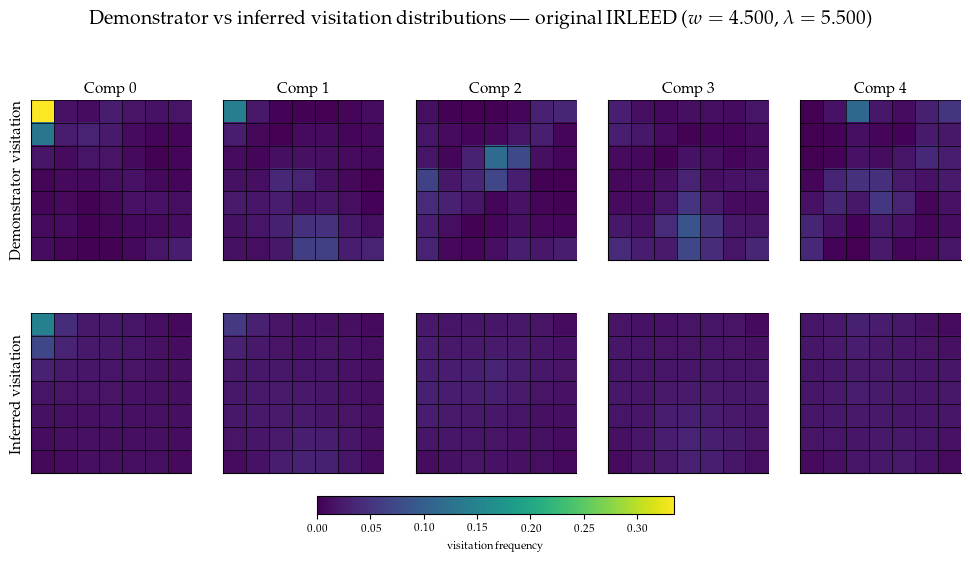

saved: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/figures/orig_demo_vs_inferred_visitation_w_4.500_lam_5.500.pdf
learned final betas: [0.92219114 0.94101001 0.91484013 0.9145825  0.91782102]
Policy action column order: ['R', 'L', 'U', 'D']


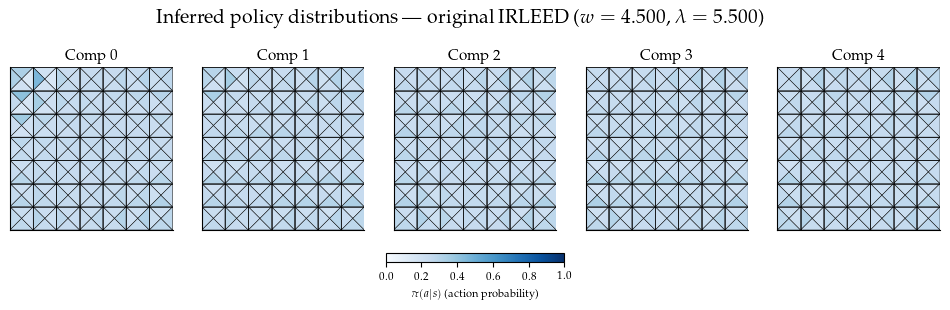

saved: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/figures/orig_inferred_policy_w_4.500_lam_5.500.pdf


In [18]:
# ============================================================
# ORIGINAL CONFIGURATION:
# demonstrator visitation vs inferred visitation
# ============================================================

ORIG_WEIGHT_SCALE = 4.500
ORIG_LAM = 5.500

orig_result_path = os.path.join(
    LOAD_DIR,
    "gridworld",
    "irleed",
    "env_1",
    f"{ORIG_WEIGHT_SCALE:.3f}",
    f"lam_{ORIG_LAM:.3f}.p"
)

with open(orig_result_path, "rb") as f:
    options_orig, data_orig = pickle.load(f)

seed_id_orig, dat_orig = get_first_valid_seed(data_orig)

print("loaded:", orig_result_path)
print("seed:", seed_id_orig)
print("available keys:", dat_orig.keys())
print("log keys:", dat_orig["log"].keys())

world, true_reward, terminal, initial = H.setup_mdp(setting=1)

# Demonstrator visitation proxy from feature expectations
mix_e_features_orig = np.array(dat_orig["mix_e_features"], dtype=np.float64)
K_orig = mix_e_features_orig.shape[0]

# Learned component rewards and betas
thetaT_orig = np.array(dat_orig["log"]["theta"][-1], dtype=np.float64)
epsT_orig = np.array(dat_orig["log"]["epsilons"][-1], dtype=np.float64)
learned_betas_orig = np.array(dat_orig["log"]["betas"][-1], dtype=np.float64)

print("mix_e_features shape:", mix_e_features_orig.shape)
print("theta_T shape:", thetaT_orig.shape)
print("eps_T shape:", epsT_orig.shape)
print("learned_betas shape:", learned_betas_orig.shape)

demo_visits_orig = []
for k in range(K_orig):
    vec = mix_e_features_orig[k].astype(np.float64)
    vec = vec / (vec.sum() + 1e-12)
    demo_visits_orig.append(vec)

inferred_reward_components_orig = [
    thetaT_orig + epsT_orig[k]
    for k in range(K_orig)
]

# Sample inferred visitations
inferred_visits_orig = []
for k in range(K_orig):
    tr_inf, _ = sample_policy_trajectories(
        world=world,
        reward_vec=inferred_reward_components_orig[k],
        beta=learned_betas_orig[k],
        initial=initial,
        terminal=terminal,
        horizon=options_orig["horizon"],
        n_traj=1500,
        discount=options_orig["discount"]
    )
    inferred_visits_orig.append(visitation_from_trajectories(world, tr_inf))

# Plot
all_maps = demo_visits_orig + inferred_visits_orig
vmin = min(np.min(v) for v in all_maps)
vmax = max(np.max(v) for v in all_maps)

component_titles_orig = [f"Comp {k}" for k in range(K_orig)]

fig, axes = plt.subplots(
    2, K_orig,
    figsize=(2.4 * K_orig, 5.8),
    squeeze=False
)
fig.suptitle(
    rf"Demonstrator vs inferred visitation distributions — original IRLEED ($w={ORIG_WEIGHT_SCALE:.3f}$, $\lambda={ORIG_LAM:.3f}$)",
    fontsize=14
)

row_labels = ["Demonstrator visitation", "Inferred visitation"]

last_im = None
for row, vlist in enumerate([demo_visits_orig, inferred_visits_orig]):
    for k in range(K_orig):
        ax = axes[row, k]
        grid = _vec_to_grid(world, vlist[k])
        last_im = ax.imshow(
            grid,
            origin="lower",
            extent=(-0.5, world.size - 0.5, -0.5, world.size - 0.5),
            vmin=vmin,
            vmax=vmax
        )

        for i in range(world.size + 1):
            ax.plot([i - 0.5, i - 0.5], [-0.5, world.size - 0.5], color="black", linewidth=0.5)
            ax.plot([-0.5, world.size - 0.5], [i - 0.5, i - 0.5], color="black", linewidth=0.5)

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        if row == 0:
            ax.set_title(component_titles_orig[k], fontsize=11)
        if k == 0:
            ax.set_ylabel(row_labels[row], fontsize=11)

cbar = fig.colorbar(
    last_im,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.04,
    pad=0.12
)
cbar.set_label("visitation frequency")

fig.subplots_adjust(bottom=0.18, top=0.90, wspace=0.20, hspace=0.04)

orig_visit_save = os.path.join(
    FIG_OUTDIR,
    f"orig_demo_vs_inferred_visitation_w_{ORIG_WEIGHT_SCALE:.3f}_lam_{ORIG_LAM:.3f}.pdf"
)
plt.savefig(orig_visit_save, bbox_inches="tight")
plt.show()
plt.close(fig)

print("saved:", orig_visit_save)
print("learned final betas:", learned_betas_orig)


# ============================================================
# ORIGINAL CONFIGURATION:
# inferred policy distributions only
# ============================================================

mapping, _ = infer_action_mapping(world, verbose=False)
action_names = [mapping[a] for a in range(world.n_actions)]
print("Policy action column order:", action_names)

K_orig = len(inferred_reward_components_orig)
component_titles_orig = [f"Comp {k}" for k in range(K_orig)]

name_to_idx = {name: i for i, name in enumerate(action_names)}
canonical = ["U", "L", "D", "R"]
reorder = [name_to_idx[c] for c in canonical]

pi_inf_list = []
for k in range(K_orig):
    pi_inf = compute_soft_policy_from_reward(
        world,
        inferred_reward_components_orig[k],
        learned_betas_orig[k],
        discount=options_orig["discount"]
    )
    pi_inf_list.append(pi_inf)

fig, axes = plt.subplots(
    1, K_orig,
    figsize=(2.4 * K_orig, 2.9),
    squeeze=False
)
fig.suptitle(
    rf"Inferred policy distributions — original IRLEED ($w={ORIG_WEIGHT_SCALE:.3f}$, $\lambda={ORIG_LAM:.3f}$)",
    fontsize=14
)

for k in range(K_orig):
    ax = axes[0, k]
    pi = pi_inf_list[k]

    for s in range(world.n_states):
        x, y = world.state_index_to_point(s)
        probs = pi[s, reorder]
        _draw_policy_glyph(ax, x, y, probs)

    for i in range(world.size + 1):
        ax.plot([i - 0.5, i - 0.5], [-0.5, world.size - 0.5], color="black", linewidth=0.5)
        ax.plot([-0.5, world.size - 0.5], [i - 0.5, i - 0.5], color="black", linewidth=0.5)

    ax.set_xlim(-0.5, world.size - 0.5)
    ax.set_ylim(-0.5, world.size - 0.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(component_titles_orig[k], fontsize=11)

norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
sm = cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.04,
    pad=0.18
)
cbar.set_label(r"$\pi(a|s)$ (action probability)")

fig.subplots_adjust(bottom=0.22, top=0.82, wspace=0.18)

orig_policy_save = os.path.join(
    FIG_OUTDIR,
    f"orig_inferred_policy_w_{ORIG_WEIGHT_SCALE:.3f}_lam_{ORIG_LAM:.3f}.pdf"
)
plt.savefig(orig_policy_save, bbox_inches="tight")
plt.show()
plt.close(fig)

print("saved:", orig_policy_save)

### Our Configuration (Without Epsilon, 3 Mixture Components)

Policy action column order: ['R', 'L', 'U', 'D']
[heterogeneous_beta_gridworld] loaded: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/results/gridworld_simple/irleed/env_1/demo_betas_0.300_1.000_5.000/noeps/baseline.p
seeds used = 100 | K = 3


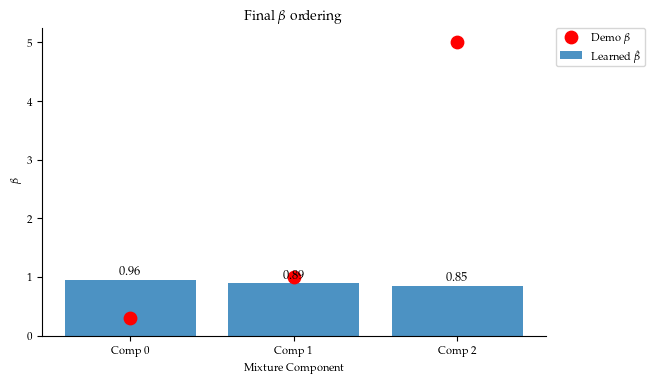

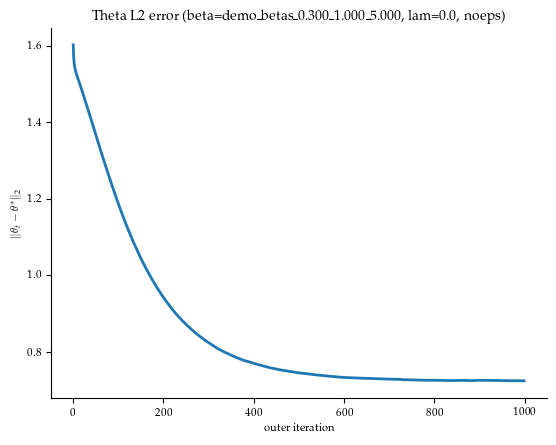

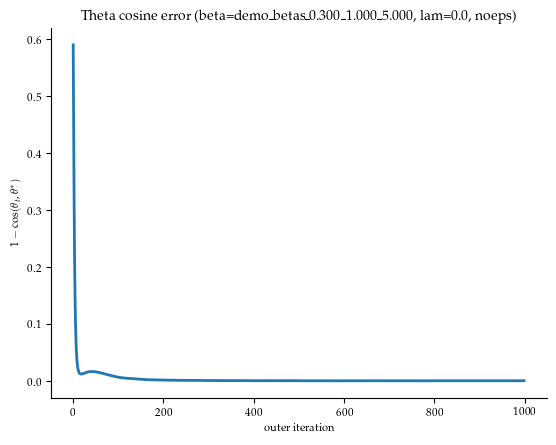

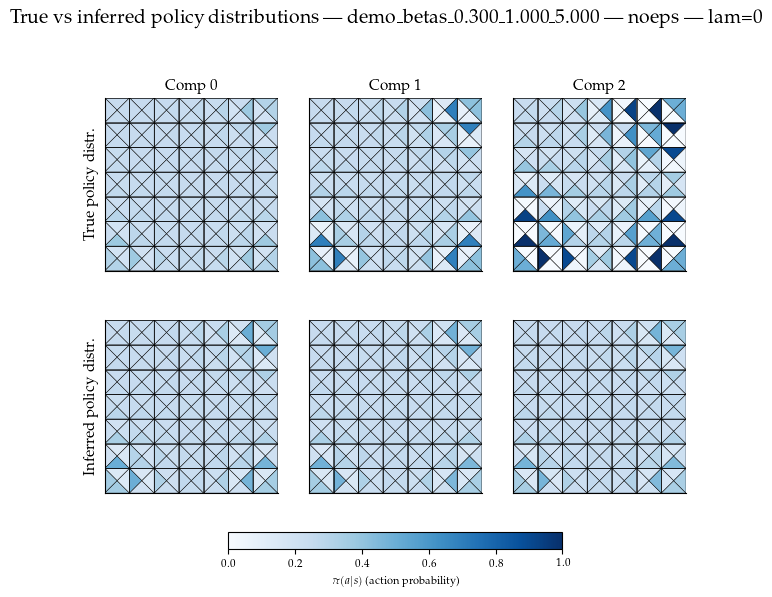

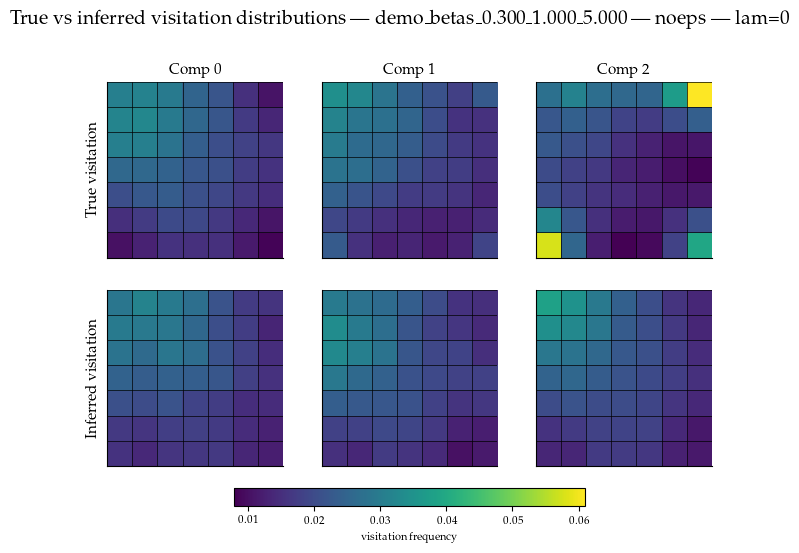

saved: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/figures/true_vs_inferred_policy_demo_betas_0.300_1.000_5.000_lam_0.000_noeps.pdf
saved: /Users/michaelzhou/Desktop/Inverse Reinforcement Learning (IRL) for Animal Behavior Understanding/IRLEED/IRLEED-main/figures/true_vs_inferred_visitation_demo_betas_0.300_1.000_5.000_lam_0.000_noeps.pdf
true betas: [0.3 1.  5. ]
learned final betas: [0.95605515 0.88993886 0.85008708]


In [20]:
# ============================================================
# FINAL EXPERIMENT CONFIG
# Shared reward, heterogeneous demonstrators with true betas
# [0.3, 1.0, 5.0], with epsilon fixed to zero.
# ============================================================

RUN_NAME = "heterogeneous_beta_gridworld"

RESULT_PATH = os.path.join(
    LOAD_DIR,
    "gridworld_simple",
    "irleed",
    "env_1",
    "demo_betas_0.300_1.000_5.000",
    "noeps",
    "baseline.p",
)

BETA_TAG = "demo_betas_0.300_1.000_5.000"
LAM = 0.0
EPS_STR = "noeps"
TRUE_BETAS = np.array([0.3, 1.0, 5.0], dtype=float)


# ============================================================
# ANALYSIS CELL
#
# Experiment used in the report:
# shared reward, heterogeneous demonstrators with true betas
# [0.3, 1.0, 5.0], with epsilon fixed to zero.
#
# We evaluate:
# - reward recovery
# - beta recovery
# - demonstrator visitation structure
# - true vs inferred policy distributions
# - true vs inferred visitation distributions
# ============================================================

USE_EPS = False
eps_str = EPS_STR
lam = LAM
beta_tag = BETA_TAG

FIG_OUTDIR = os.path.join(ROOT, "figures")
os.makedirs(FIG_OUTDIR, exist_ok=True)

# Gridworld for plotting (env_id=1 => setting=1, 7x7 world)
world, true_reward, terminal, initial = H.setup_mdp(setting=1)

# Infer action-name mapping for policy visualizations
mapping, _ = infer_action_mapping(world, verbose=False)
action_names = [mapping[a] for a in range(world.n_actions)]
print("Policy action column order:", action_names)

# Load saved results from disk and summarize them
summary = summarize_run(RESULT_PATH)

options = summary["options"]
data = summary["data"]
path = summary["path"]
returns_mean = summary["returns_mean"]
theta_pair_mean = summary["theta_pair_mean"]
feat_mean = summary["feat_mean"]
eps_final_mean = summary["eps_final_mean"]
eps_hist_mean = summary["eps_hist_mean"]
betas_hist_mean = summary["betas_hist_mean"]
theta_hist_mean = summary["theta_hist_mean"]
count = summary["count"]
K = summary["K"]
T = summary["T"]
seed_id = summary["seed_id"]
dat = summary["dat"]

beta_true_mean = summary["beta_true_mean"]
if beta_true_mean is None:
    beta_true_mean = TRUE_BETAS

print(f"[{RUN_NAME}] loaded: {path}")
print(f"seeds used = {count} | K = {K}")

# ------------------------------------------------------------
# Beta-related plots
# ------------------------------------------------------------
if betas_hist_mean is not None:
    plot_beta_vs_iter(
        betas_hist_mean,
        beta_tag,
        lam,
        eps_str,
        FIG_OUTDIR,
        true_betas=beta_true_mean
    )

    plot_sorted_beta_ordering(
        betas_hist_mean,
        beta_true_mean,
        beta_tag,
        lam,
        eps_str,
        FIG_OUTDIR
    )

    plot_beta_component_errors_vs_iter(
        betas_hist_mean,
        beta_true_mean,
        beta_tag,
        lam,
        eps_str,
        FIG_OUTDIR
    )

    plot_final_beta_vs_true(
        betas_hist_mean,
        beta_true_mean,
        beta_tag,
        lam,
        eps_str,
        FIG_OUTDIR
    )

    plot_final_beta_bar(
        betas_hist_mean,
        beta_true_mean
    )

# ------------------------------------------------------------
# Theta / reward recovery plots
# ------------------------------------------------------------
if theta_hist_mean is not None:
    plot_theta_error_vs_iter(
        theta_hist_mean, true_reward, beta_tag, lam, eps_str, FIG_OUTDIR
    )
    plot_reward_correlation_vs_iter(
        theta_hist_mean, true_reward, beta_tag, lam, eps_str, FIG_OUTDIR
    )
    plot_reward_snapshots(
        theta_hist_mean, true_reward, world, beta_tag, lam, eps_str, FIG_OUTDIR
    )
    plot_reward_l2_vs_iter(
        theta_hist_mean, true_reward, beta_tag, lam, eps_str, FIG_OUTDIR
    )

theta0 = theta_pair_mean[0]
thetaT = theta_pair_mean[1]

plot_reward_triptych(
    world,
    true_reward,
    theta0,
    thetaT,
    beta_tag,
    lam,
    eps_str,
    FIG_OUTDIR
)

# ------------------------------------------------------------
# Demonstrator visitation heatmaps
# ------------------------------------------------------------
plot_component_visitation_heatmaps(
    world=world,
    mix_traj=dat["mix_traj"],
    terminal_states=terminal,
    beta_tag=beta_tag,
    lam=lam,
    eps_str=eps_str,
    save_dir=FIG_OUTDIR,
    preterminal=False,
)

# ------------------------------------------------------------
# Optional per-component trajectory grids / diagnostics
# ------------------------------------------------------------
# for comp_id, trajectories in enumerate(dat["mix_traj"]):
#     plot_trajectory_grid(
#         world,
#         trajectories,
#         n=200,
#         ncols=10,
#         title=f"{RUN_NAME} | seed {seed_id} | comp {comp_id} trajectories",
#         terminal_states=terminal
#     )
#
#     plot_visit_diagnostics(
#         world,
#         trajectories,
#         terminal,
#         title_prefix=f"{RUN_NAME} | component {comp_id}"
#     )

# ------------------------------------------------------------
# True vs inferred policy / visitation comparisons
# ------------------------------------------------------------
thetaT = np.array(theta_pair_mean[1], dtype=np.float64)
learned_betas = np.array(betas_hist_mean[-1], dtype=np.float64)

K_case = len(learned_betas)

# In this experiment, all components share the same true reward
true_reward_components = [
    np.array(true_reward, dtype=np.float64).copy()
    for _ in range(K_case)
]

# In this experiment, all inferred components also share the same learned reward
# because epsilon is fixed to zero
inferred_reward_components = [
    thetaT.copy()
    for _ in range(K_case)
]

true_betas = np.array(dat["true_betas"], dtype=np.float64)

component_titles = [f"Comp {k}" for k in range(K_case)]

policy_save = os.path.join(
    FIG_OUTDIR,
    f"true_vs_inferred_policy_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf"
)
visit_save = os.path.join(
    FIG_OUTDIR,
    f"true_vs_inferred_visitation_{beta_tag}_lam_{lam:.3f}_{eps_str}.pdf"
)

pi_true_list, pi_inf_list = plot_true_vs_inferred_policy_panels(
    world=world,
    true_reward_components=true_reward_components,
    inferred_reward_components=inferred_reward_components,
    true_betas=true_betas,
    learned_betas=learned_betas,
    initial=initial,
    terminal=terminal,
    discount=options["discount"],
    action_names=action_names,
    component_titles=component_titles,
    fig_title=f"True vs inferred policy distributions — {beta_tag} — {eps_str} — lam={lam:g}",
    save_path=policy_save,
)

true_visits, inf_visits = plot_true_vs_inferred_visitation_panels(
    world=world,
    true_reward_components=true_reward_components,
    inferred_reward_components=inferred_reward_components,
    true_betas=true_betas,
    learned_betas=learned_betas,
    initial=initial,
    terminal=terminal,
    horizon=options["horizon"],
    n_traj=1500,
    discount=options["discount"],
    component_titles=component_titles,
    fig_title=f"True vs inferred visitation distributions — {beta_tag} — {eps_str} — lam={lam:g}",
    save_path=visit_save,
)

print("saved:", policy_save)
print("saved:", visit_save)
print("true betas:", true_betas)
print("learned final betas:", learned_betas)